# Section 2.1 Feature Selection

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5), "Python 3.5 or later is required."

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20", "Scikit-Learn 0.20 or later is required."

# Common imports
import os
import time
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib and Seaborn
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set()

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def feature_selection(X, y, n_estimators=100, random_state=42):
    """
    Perform feature selection using Random Forest based on OOB feature importance.
    
    Parameters:
    - X (DataFrame): Feature dataset
    - y (Series): Output variable
    - n_estimators (int): Number of trees in the forest (default=100)
    - random_state (int): Random state for reproducibility (default=42)
    
    Returns:
    - removed_features (list): List of removed features in the order they were dropped
    - rmse_list (list): RMSE values for each iteration
    - r2_list (list): R2 values for each iteration
    """

    X_loop = X.copy()  # avoid modifying the original data
    
    # Initialize lists to store results
    rmse_list = []
    r2_list = []
    important_features = []
    
    # Set up the Random Forest model with OOB enabled
    model = RandomForestRegressor(n_estimators=n_estimators, 
                                  oob_score=True, 
                                  random_state=random_state)
    
    # Loop until there are no features left
    while X_loop.shape[1] > 0:
        # Fit the model on the current dataset
        model.fit(X_loop, y)
        
        # Calculate OOB RMSE and R2
        oob_rmse = np.sqrt(mean_squared_error(y, model.oob_prediction_))
        oob_r2 = r2_score(y, model.oob_prediction_)
        
        # Record the performance metrics
        rmse_list.append(oob_rmse)
        r2_list.append(oob_r2)
        
        # Determine feature importances and identify the least important feature
        feature_importances = model.feature_importances_
        least_important_feature = X_loop.columns[np.argmin(feature_importances)]
        important_features.append(least_important_feature)
    
        
        # Drop the least important feature
        X_loop = X_loop.drop(columns=[least_important_feature])
    
    print("Feature Selection Complete")
    
    
    # Return the results as a dictionary
    return {
        "important_features": important_features,
        "rmse_list": rmse_list,
        "r2_list": r2_list
    }

In [3]:
# Mapping of weather codes to descriptive names
synop_mapping = {
    0: 'Clear',
    3: 'Dust Storm',
    4: 'Fog',
    5: 'Drizzle',
    6: 'Rain',
    7: 'Snow',
    8: 'Showers'
}

In [4]:
def plot_feature_selection_base(important_features, rmse_list, r2_list, file_prefix, synop_mapping=synop_mapping, point=None):
    """
    Base function to plot RMSE and R2 scores by the remaining important features.

    Parameters:
    - important_features (list): List of retained important features in order of selection.
    - rmse_list (list): RMSE values for each iteration of feature selection.
    - r2_list (list): R2 values for each iteration of feature selection.
    - file_prefix (str): Prefix for the filename to save the plot.
    - synop_mapping (dict): Mapping of weather codes to descriptive names.
    - point (str, optional): Feature name where the tuning point is applied (for green line).
    """
    # Extract model type, channel, and weather code from file_prefix
    parts = file_prefix.split('_')
    channel = parts[0]  # "FSO" or "RF"
    model_type = parts[1]  # "Generic" or "Specific"
    weather_code = int(parts[2]) if model_type != "Generic" else None
    weather_name = synop_mapping.get(weather_code, "Unknown") if weather_code is not None else "All Weather"

    # Set a style for white background with black grid
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create a figure and primary y-axis
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Plot RMSE on the primary y-axis
    ax1.plot(important_features, rmse_list, marker='o', color='b', label='OOB RMSE', linewidth=2, markersize=8)
    ax1.set_ylabel('OOB RMSE (dB)', color='b', fontsize=24)
    ax1.tick_params(axis='y', labelcolor='b', labelsize=24)
    ax1.set_xticks(range(len(important_features)))
    ax1.set_xticklabels(important_features, rotation=90, fontsize=20)
    ax1.grid(visible=True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add a vertical green line if a tuning point is provided
    if point:
        x_index = important_features.index(point) + 0.5
        ax1.axvline(x=x_index, color='green', linestyle='--', linewidth=4, label='Threshold')

    # Create a secondary y-axis for R2
    ax2 = ax1.twinx()
    ax2.plot(important_features, r2_list, marker='o', color='r', label='OOB R2', linewidth=2, markersize=8)
    ax2.set_ylabel('OOB R2', color='r', fontsize=22)
    ax2.tick_params(axis='y', labelcolor='r', labelsize=22)
    ax2.grid(visible=False)

    # Add title
    plt.title(f"{channel} Channel - {model_type} Model - {weather_name}", fontsize=22)
    fig.tight_layout()

    return fig, ax1


def plot_feature_rank(important_features, rmse_list, r2_list, file_prefix, synop_mapping=synop_mapping):
    """
    Plot RMSE and R2 scores by the remaining important features without a green line.
    """
    fig, ax1 = plot_feature_selection_base(important_features, rmse_list, r2_list, file_prefix, synop_mapping)
    
    # Save the plot
    output_dir = 'Figure/Feature_Selection'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'{file_prefix}_feature_selection_results.eps'), format='eps')
    plt.savefig(os.path.join(output_dir, f'{file_prefix}_feature_selection_results.jpg'), format='jpg')
    plt.show()


def plot_green_line(important_features, rmse_list, r2_list, file_prefix, point, synop_mapping=synop_mapping):
    """
    Plot RMSE and R2 scores by the remaining important features with a green line.
    """
    fig, ax1 = plot_feature_selection_base(important_features, rmse_list, r2_list, file_prefix, synop_mapping, point=point)
    
    # Save the plot
    output_dir = 'Figure/Feature_Selection'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'{file_prefix}_greenline_results.eps'), format='eps')
    plt.savefig(os.path.join(output_dir, f'{file_prefix}_greenline_results.jpg'), format='jpg')
    plt.show()

In [5]:
def save_important_features(important_features, point, file_prefix, output_dict):
    """
    Save the important features for each model after the turning point in the desired format.

    Parameters:
    - important_features (list): List of retained important features in order of selection.
    - point (str): Feature name where the turning point is applied.
    - file_prefix (str): Prefix for the filename to identify the model (e.g., "FSO_Specific0").
    - output_dict (dict): Dictionary to store the important features for each model.
    """
   
    # Extract model type, channel, and weather code from file_prefix
    parts = file_prefix.split('_')
    channel = parts[0]  # "FSO" or "RF"
    model_type = parts[1]  # "Generic" or "Specific"


    # Check if the turning point exists in the important features
    if point in important_features:
        # Slice the features up to and including the turning point
        updated_features = important_features[important_features.index(point) + 1:]

        # Save the updated features into the output dictionary
        if channel not in output_dict:
            output_dict[channel] = {}
        output_dict[channel][model_type] = updated_features

        # Print the updated features for the model
        print(f"Updated important features for {channel} - {model_type}: {updated_features}")
    else:
        print(f"Warning: Turning point '{point}' not found in important features for {file_prefix}.")

In [6]:
# Load generic datasets
X_data = {
    "X_Generic": pd.read_csv("Data/Splitting/Train/Generic/X/X_train.csv")
}
y_data_FSO = {
    "y_Generic_FSO": pd.read_csv("Data/Splitting/Train/Generic/Y/y_train_FSO.csv").squeeze()
}
y_data_RF = {
    "y_Generic_RF": pd.read_csv("Data/Splitting/Train/Generic/Y/y_train_RF.csv").squeeze()
}

# Load specific datasets in a loop
for i in [0, 3, 4, 5, 6, 7, 8]:
    X_data[f"X_Specific{i}"] = pd.read_csv(f"Data/Splitting/Train/Specific/X/train_X_SC_{i}.csv")
    y_data_FSO[f"y_Specific{i}_FSO"] = pd.read_csv(f"Data/Splitting/Train/Specific/Y/train_y_FSO_SC_{i}.csv").squeeze()
    y_data_RF[f"y_Specific{i}_RF"] = pd.read_csv(f"Data/Splitting/Train/Specific/Y/train_y_RF_SC_{i}.csv").squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


**(1) Feature Selection for Generic Model on FSO Attenuation**

In [7]:
FSO_Generic_results = feature_selection(X_data["X_Generic"].drop(columns=["Freq"]), y_data_FSO["y_Generic_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


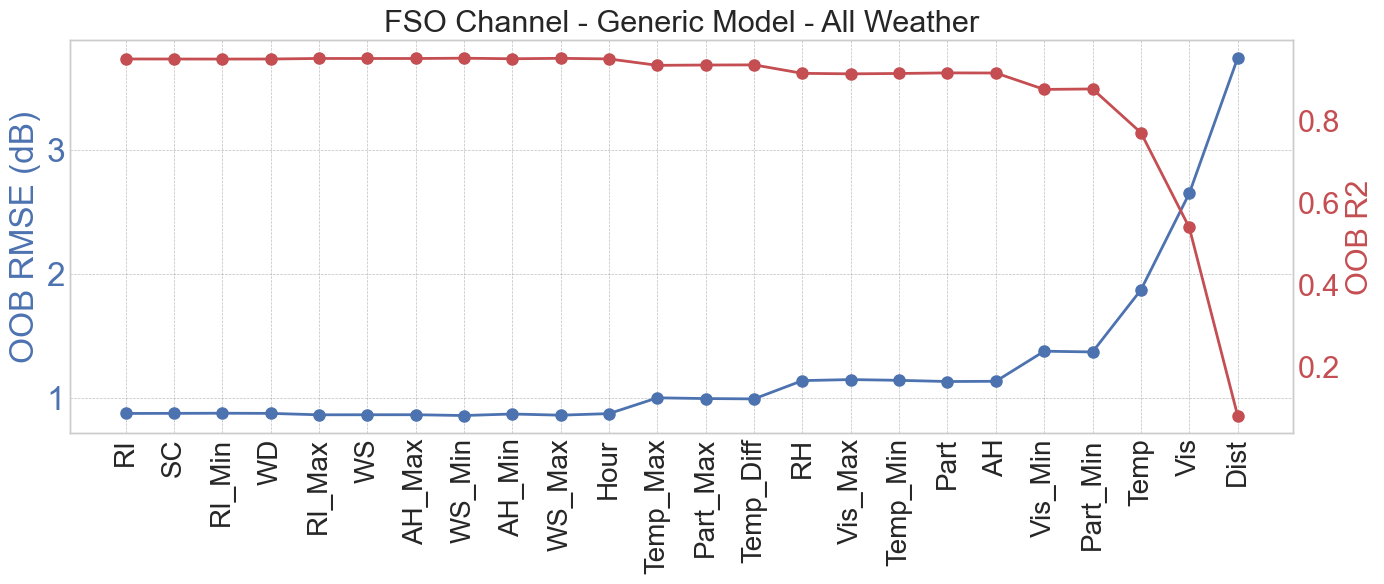

In [8]:
plot_feature_rank(FSO_Generic_results["important_features"], 
                  FSO_Generic_results["rmse_list"], 
                  FSO_Generic_results["r2_list"],
                  file_prefix="FSO_Generic")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


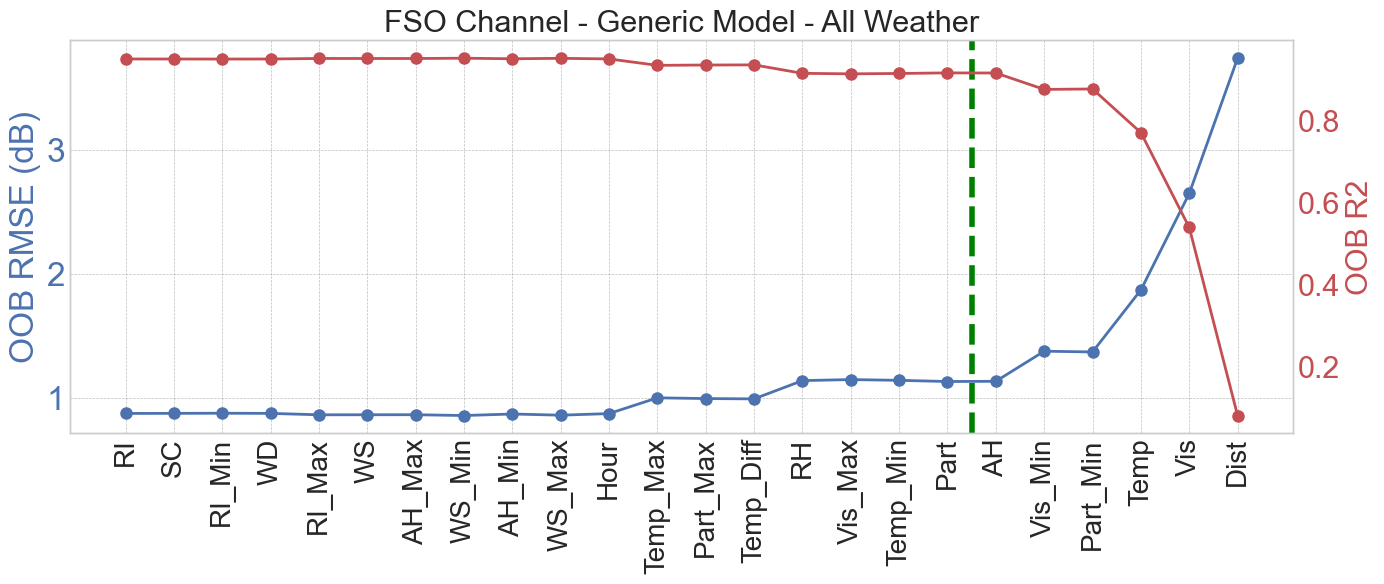

In [9]:
plot_green_line(FSO_Generic_results["important_features"],
                FSO_Generic_results["rmse_list"], 
                FSO_Generic_results["r2_list"],
                file_prefix="FSO_Generic",
                point="Part")

In [10]:
important_features = {}
save_important_features(FSO_Generic_results["important_features"], 
                        point="Part", 
                        file_prefix="FSO_Generic", 
                        output_dict=important_features)

Updated important features for FSO - Generic: ['AH', 'Vis_Min', 'Part_Min', 'Temp', 'Vis', 'Dist']


**(2) Feature Selection for Specific Model on FSO Attenuation**

In [11]:
FSO_Specific0_results = feature_selection(X_data["X_Specific0"].drop(columns=["Freq"]), y_data_FSO["y_Specific0_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


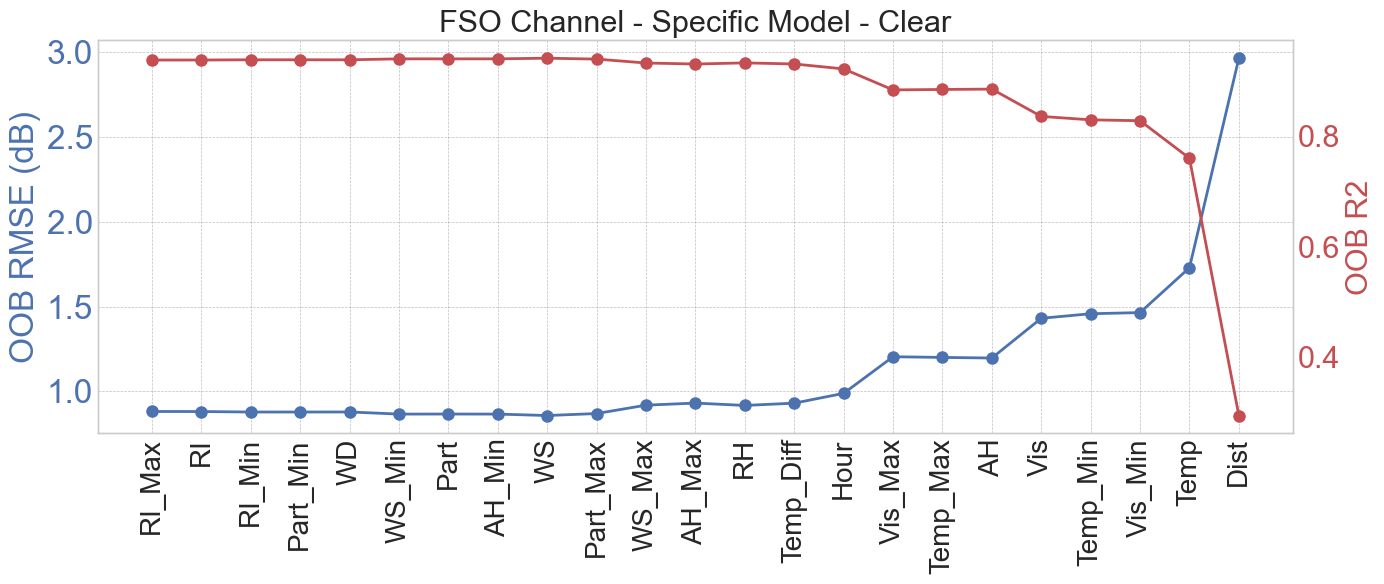

In [12]:
plot_feature_rank(FSO_Specific0_results["important_features"], 
                  FSO_Specific0_results["rmse_list"], 
                  FSO_Specific0_results["r2_list"],
                  file_prefix="FSO_Specific_0")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


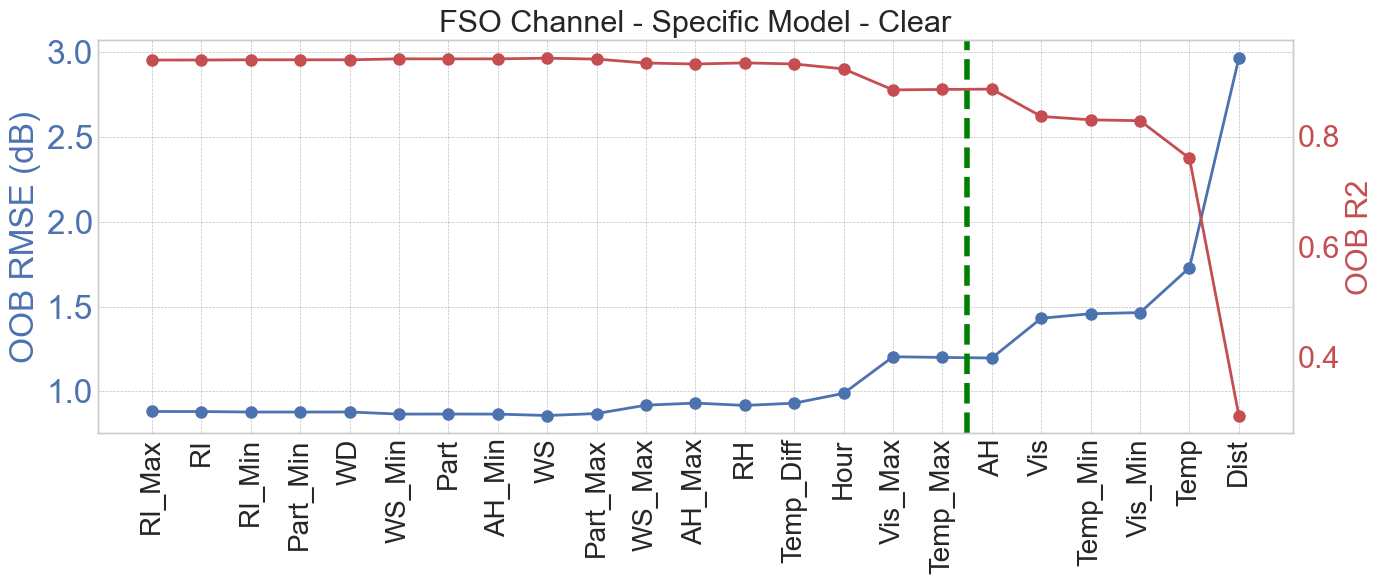

In [13]:
plot_green_line(FSO_Specific0_results["important_features"], 
                FSO_Specific0_results["rmse_list"], 
                FSO_Specific0_results["r2_list"],
                file_prefix="FSO_Specific_0",
                point="Temp_Max")

In [14]:
save_important_features(FSO_Specific0_results["important_features"],
                        point="Temp_Max", 
                        file_prefix="FSO_Specific0", 
                        output_dict=important_features)

Updated important features for FSO - Specific0: ['AH', 'Vis', 'Temp_Min', 'Vis_Min', 'Temp', 'Dist']


In [15]:
FSO_Specific3_results = feature_selection(X_data["X_Specific3"].drop(columns=["Freq"]), y_data_FSO["y_Specific3_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


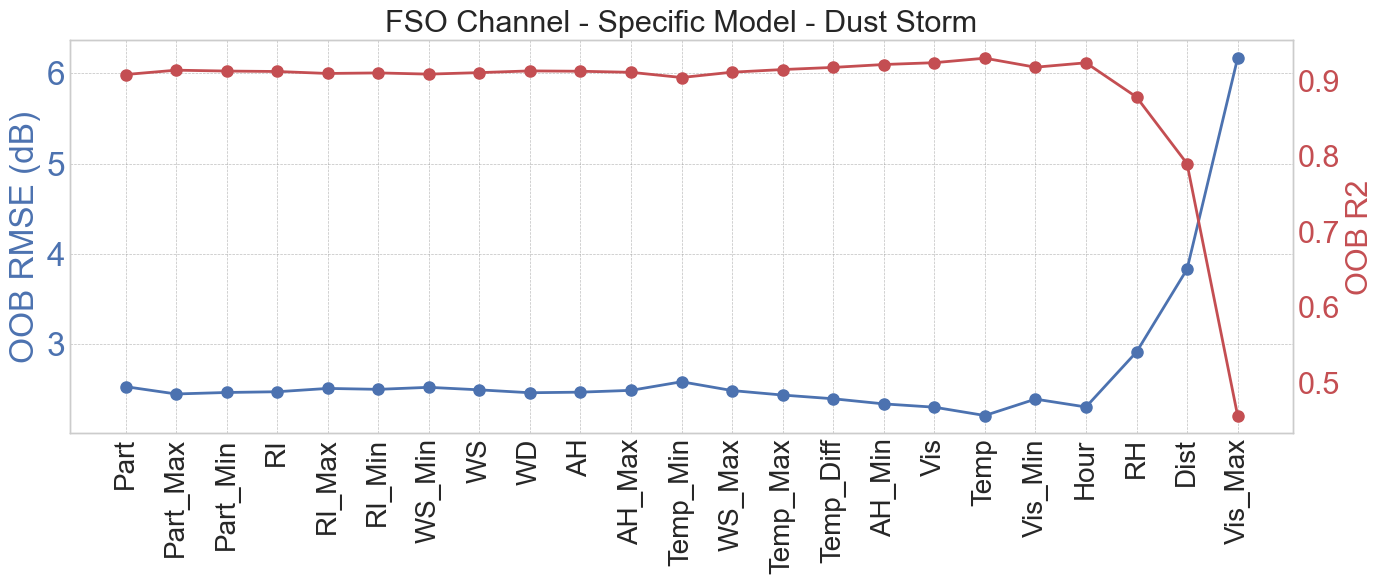

In [16]:
plot_feature_rank(FSO_Specific3_results["important_features"], 
                  FSO_Specific3_results["rmse_list"], 
                  FSO_Specific3_results["r2_list"],
                  file_prefix="FSO_Specific_3")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


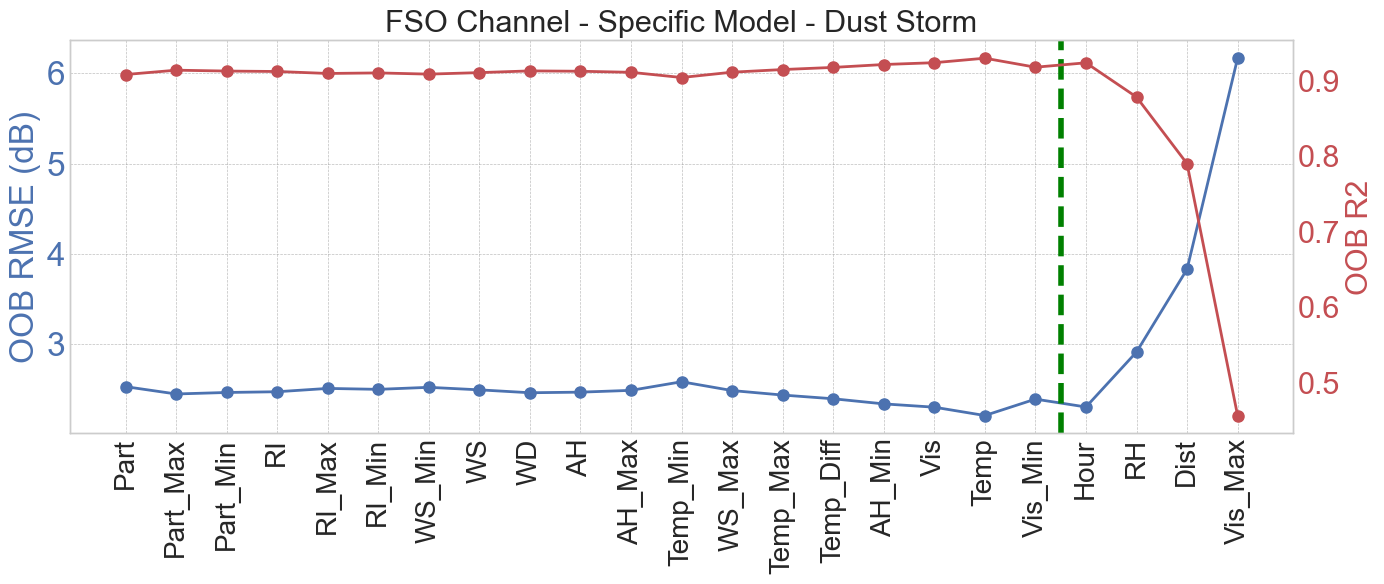

In [17]:
plot_green_line(FSO_Specific3_results["important_features"], 
                FSO_Specific3_results["rmse_list"], 
                FSO_Specific3_results["r2_list"],
                file_prefix="FSO_Specific_3",
                point="Vis_Min")

In [18]:
save_important_features(FSO_Specific3_results["important_features"],
                        point="Vis_Min", 
                        file_prefix="FSO_Specific3", 
                        output_dict=important_features)

Updated important features for FSO - Specific3: ['Hour', 'RH', 'Dist', 'Vis_Max']


In [19]:
FSO_Specific4_results = feature_selection(X_data["X_Specific4"].drop(columns=["Freq"]), y_data_FSO["y_Specific4_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


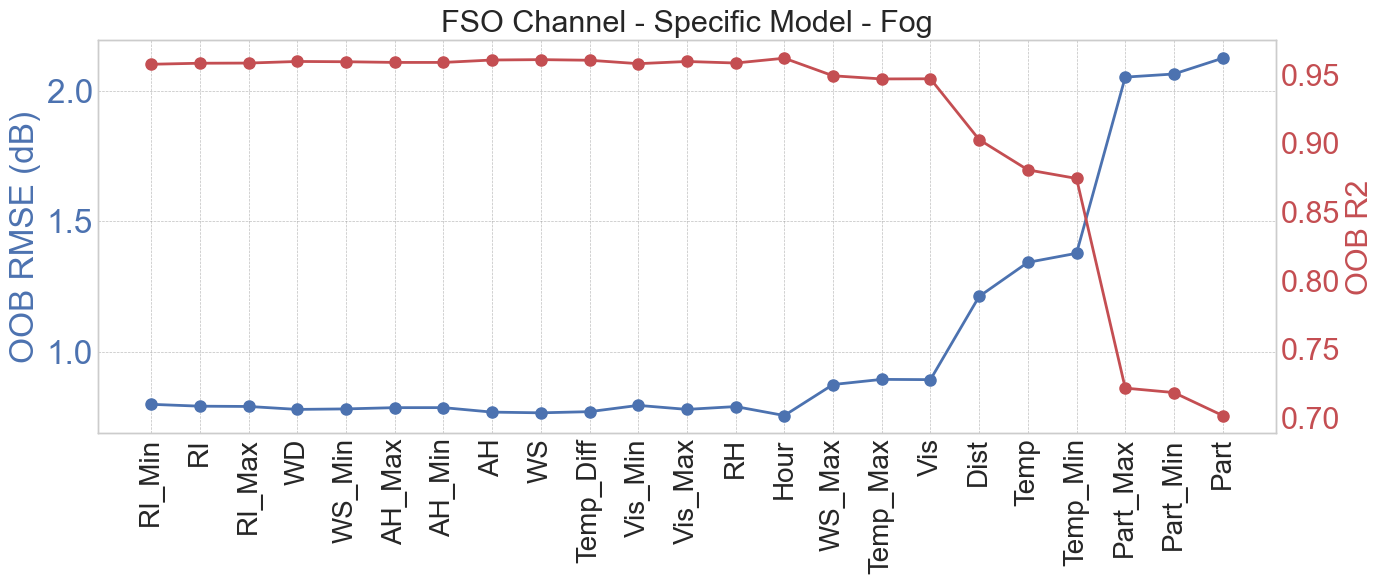

In [20]:
plot_feature_rank(FSO_Specific4_results["important_features"], 
                  FSO_Specific4_results["rmse_list"], 
                  FSO_Specific4_results["r2_list"],
                  file_prefix="FSO_Specific_4")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


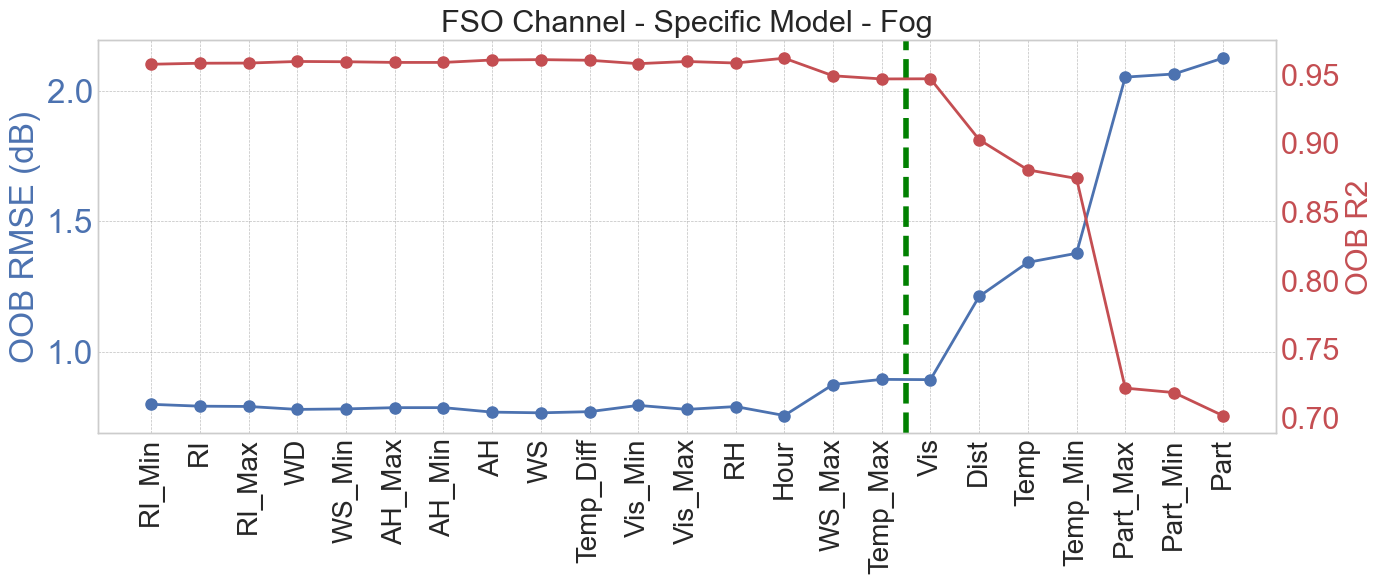

In [21]:
plot_green_line(FSO_Specific4_results["important_features"], 
                FSO_Specific4_results["rmse_list"], 
                FSO_Specific4_results["r2_list"],
                file_prefix="FSO_Specific_4",
                point="Temp_Max")

In [22]:
save_important_features(FSO_Specific4_results["important_features"],
                        point="Temp_Max", 
                        file_prefix="FSO_Specific4", 
                        output_dict=important_features)

Updated important features for FSO - Specific4: ['Vis', 'Dist', 'Temp', 'Temp_Min', 'Part_Max', 'Part_Min', 'Part']


In [23]:
FSO_Specific5_results = feature_selection(X_data["X_Specific5"].drop(columns=["Freq"]), y_data_FSO["y_Specific5_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


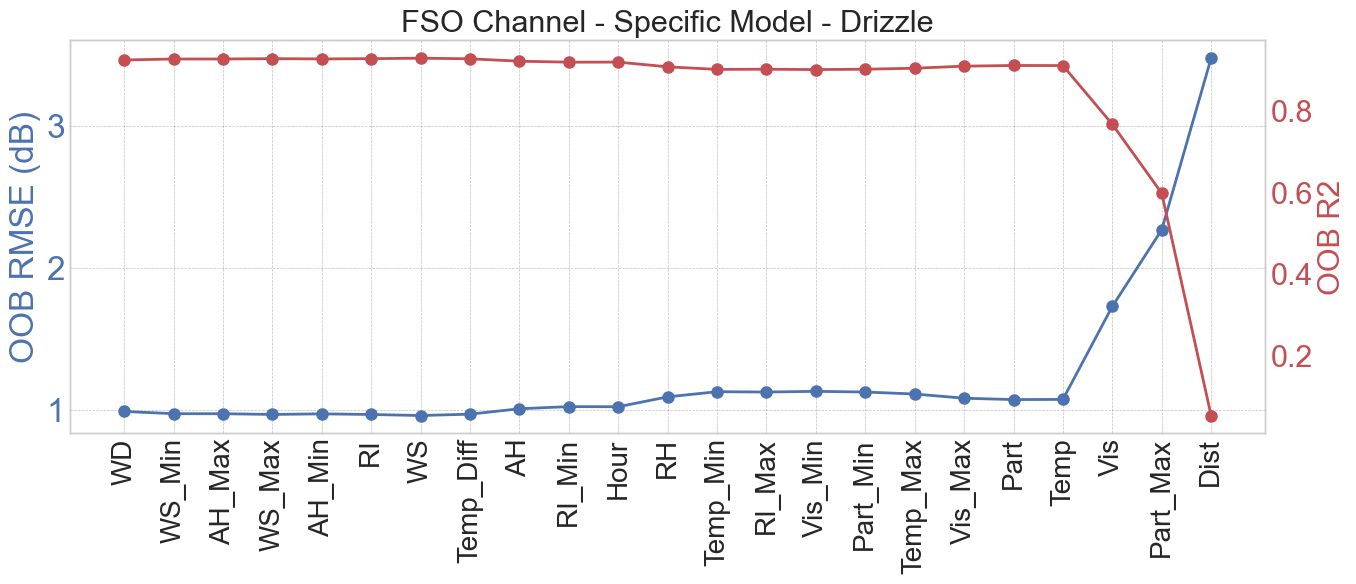

In [24]:
plot_feature_rank(FSO_Specific5_results["important_features"], 
                  FSO_Specific5_results["rmse_list"], 
                  FSO_Specific5_results["r2_list"],
                  file_prefix="FSO_Specific_5")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


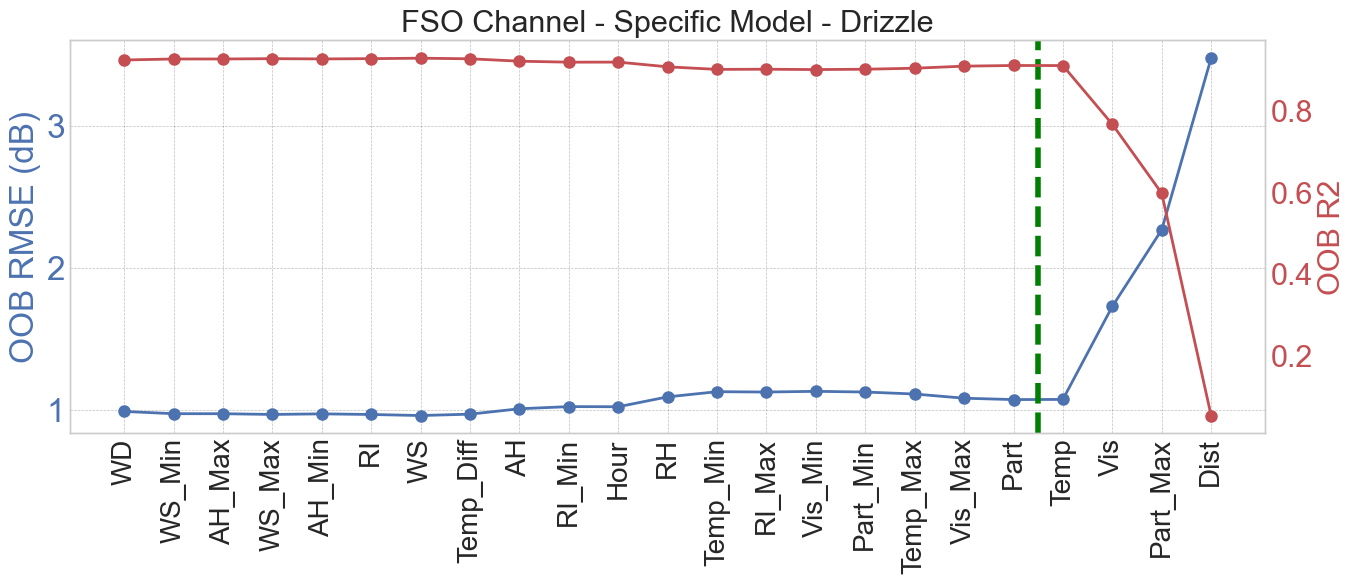

In [25]:
plot_green_line(FSO_Specific5_results["important_features"], 
                FSO_Specific5_results["rmse_list"], 
                FSO_Specific5_results["r2_list"],
                file_prefix="FSO_Specific_5",
                point="Part")

In [26]:
save_important_features(FSO_Specific5_results["important_features"],
                        point="Part", 
                        file_prefix="FSO_Specific5", 
                        output_dict=important_features)

Updated important features for FSO - Specific5: ['Temp', 'Vis', 'Part_Max', 'Dist']


In [27]:
FSO_Specific6_results = feature_selection(X_data["X_Specific6"].drop(columns=["Freq"]), y_data_FSO["y_Specific6_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


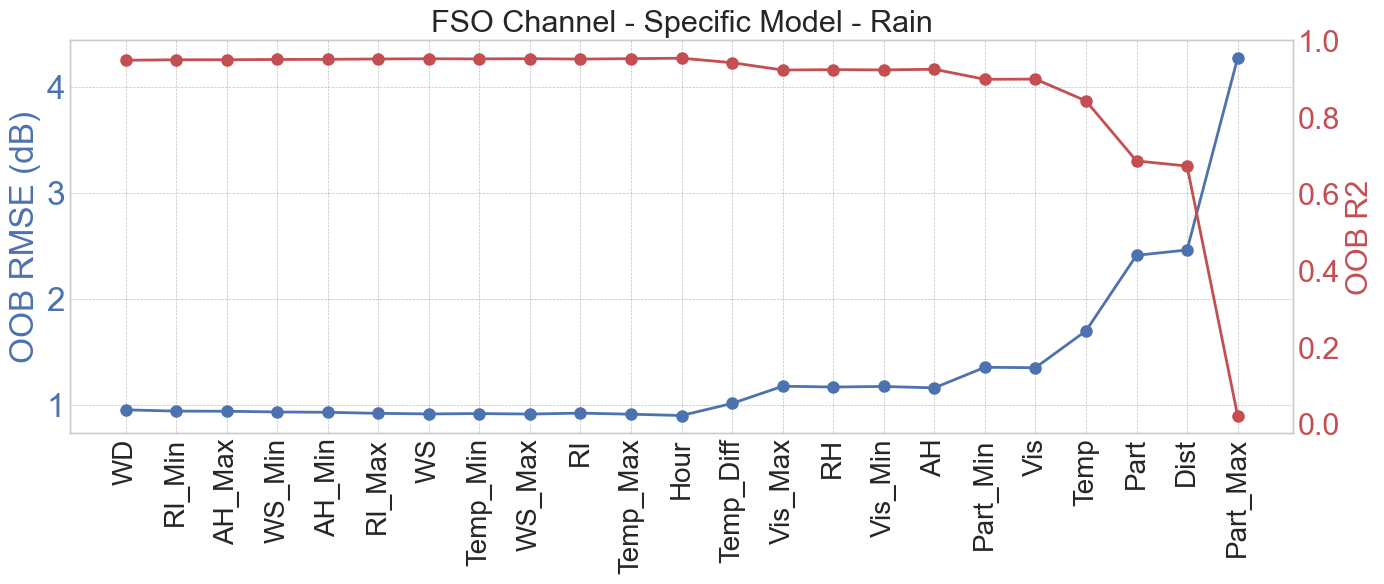

In [28]:
plot_feature_rank(FSO_Specific6_results["important_features"], 
                  FSO_Specific6_results["rmse_list"], 
                  FSO_Specific6_results["r2_list"],
                  file_prefix="FSO_Specific_6")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


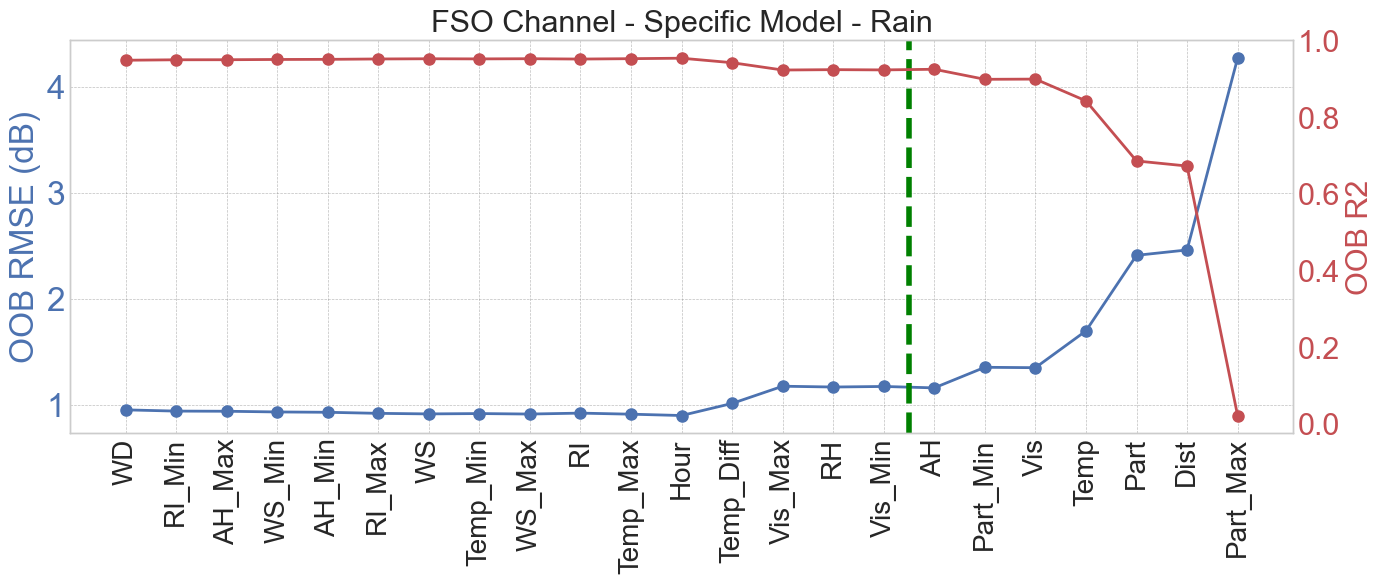

In [29]:
plot_green_line(FSO_Specific6_results["important_features"], 
                FSO_Specific6_results["rmse_list"], 
                FSO_Specific6_results["r2_list"],
                file_prefix="FSO_Specific_6",
                point="Vis_Min")

In [30]:
save_important_features(FSO_Specific6_results["important_features"],
                        point="Vis_Min", 
                        file_prefix="FSO_Specific6", 
                        output_dict=important_features)

Updated important features for FSO - Specific6: ['AH', 'Part_Min', 'Vis', 'Temp', 'Part', 'Dist', 'Part_Max']


In [31]:
FSO_Specific7_results = feature_selection(X_data["X_Specific7"].drop(columns=["Freq"]), y_data_FSO["y_Specific7_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


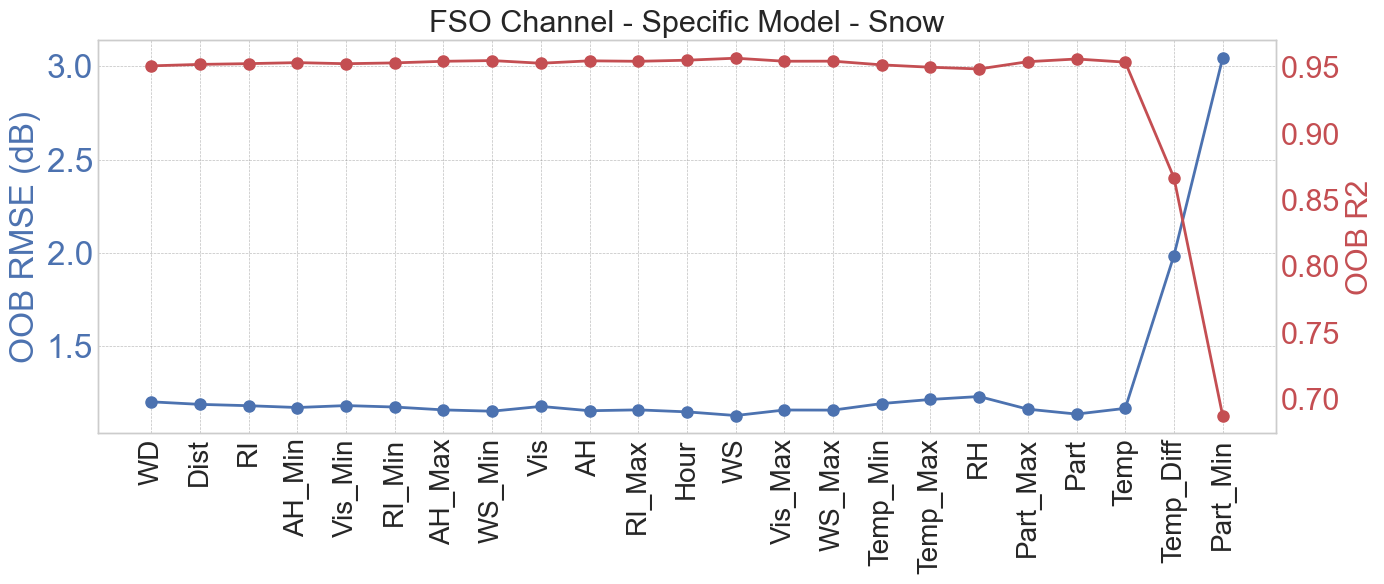

In [32]:
plot_feature_rank(FSO_Specific7_results["important_features"], 
                  FSO_Specific7_results["rmse_list"], 
                  FSO_Specific7_results["r2_list"],
                  file_prefix="FSO_Specific_7")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


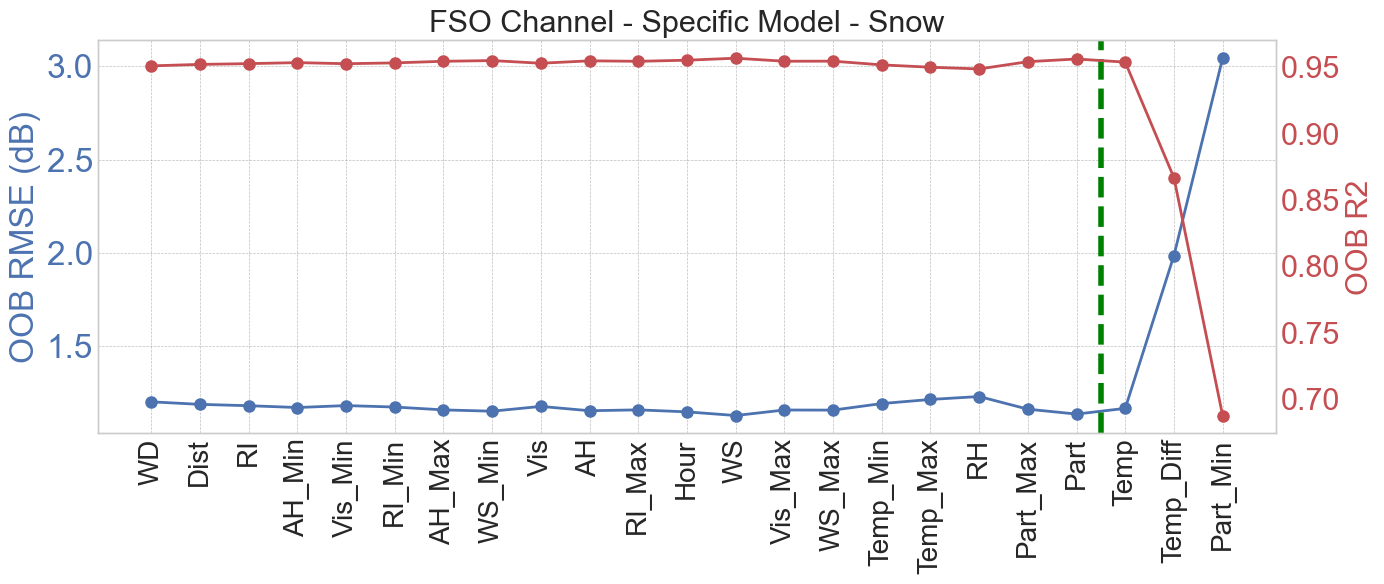

In [33]:
plot_green_line(FSO_Specific7_results["important_features"], 
                FSO_Specific7_results["rmse_list"], 
                FSO_Specific7_results["r2_list"],
                file_prefix="FSO_Specific_7",
                point="Part")

In [34]:
save_important_features(FSO_Specific7_results["important_features"],
                        point="Part", 
                        file_prefix="FSO_Specific7", 
                        output_dict=important_features)

Updated important features for FSO - Specific7: ['Temp', 'Temp_Diff', 'Part_Min']


In [35]:
FSO_Specific8_results = feature_selection(X_data["X_Specific8"].drop(columns=["Freq"]), y_data_FSO["y_Specific8_FSO"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


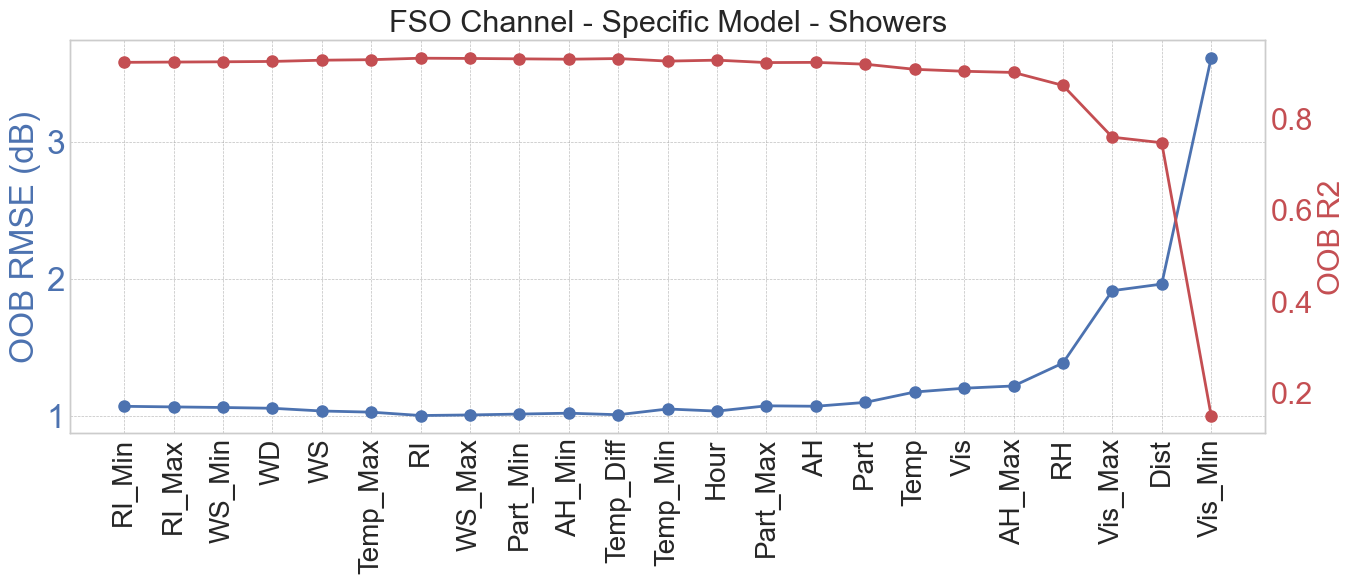

In [36]:
plot_feature_rank(FSO_Specific8_results["important_features"], 
                  FSO_Specific8_results["rmse_list"], 
                  FSO_Specific8_results["r2_list"],
                  file_prefix="FSO_Specific_8")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


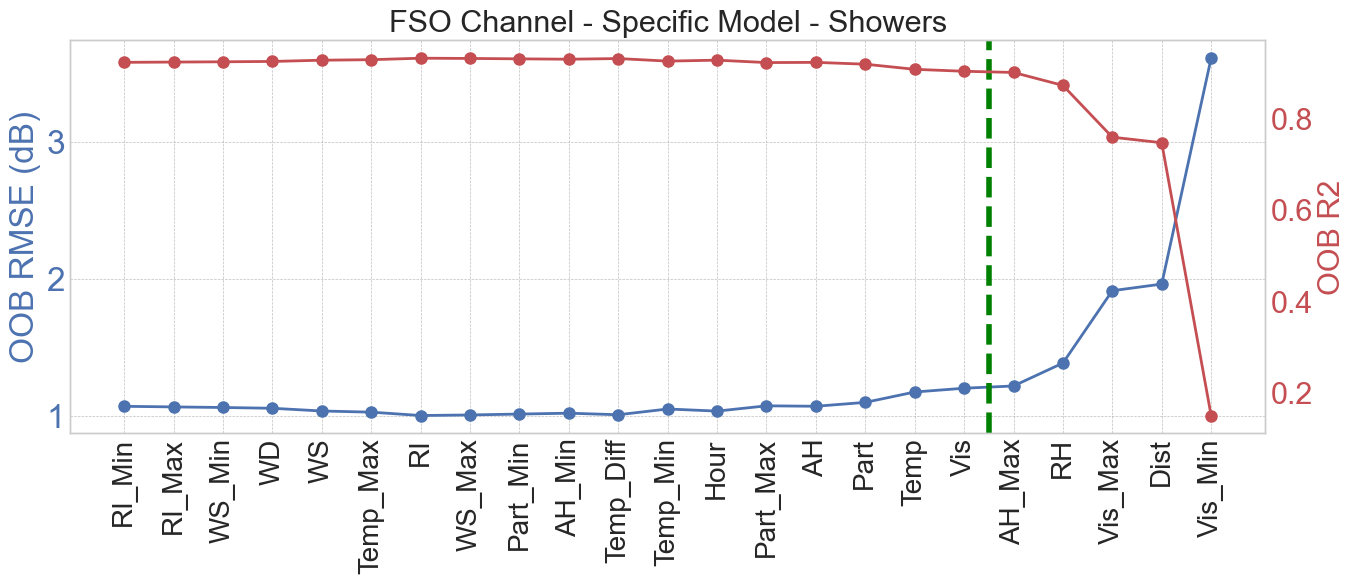

In [37]:
plot_green_line(FSO_Specific8_results["important_features"], 
                FSO_Specific8_results["rmse_list"], 
                FSO_Specific8_results["r2_list"],
                file_prefix="FSO_Specific_8",
                point="Vis")

In [38]:
save_important_features(FSO_Specific8_results["important_features"],
                        point="Vis", 
                        file_prefix="FSO_Specific8", 
                        output_dict=important_features)

Updated important features for FSO - Specific8: ['AH_Max', 'RH', 'Vis_Max', 'Dist', 'Vis_Min']


**(3) Feature Selection for Generic Model on RF Attenuation**

In [39]:
RF_Generic_results = feature_selection(X_data["X_Generic"], y_data_RF["y_Generic_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


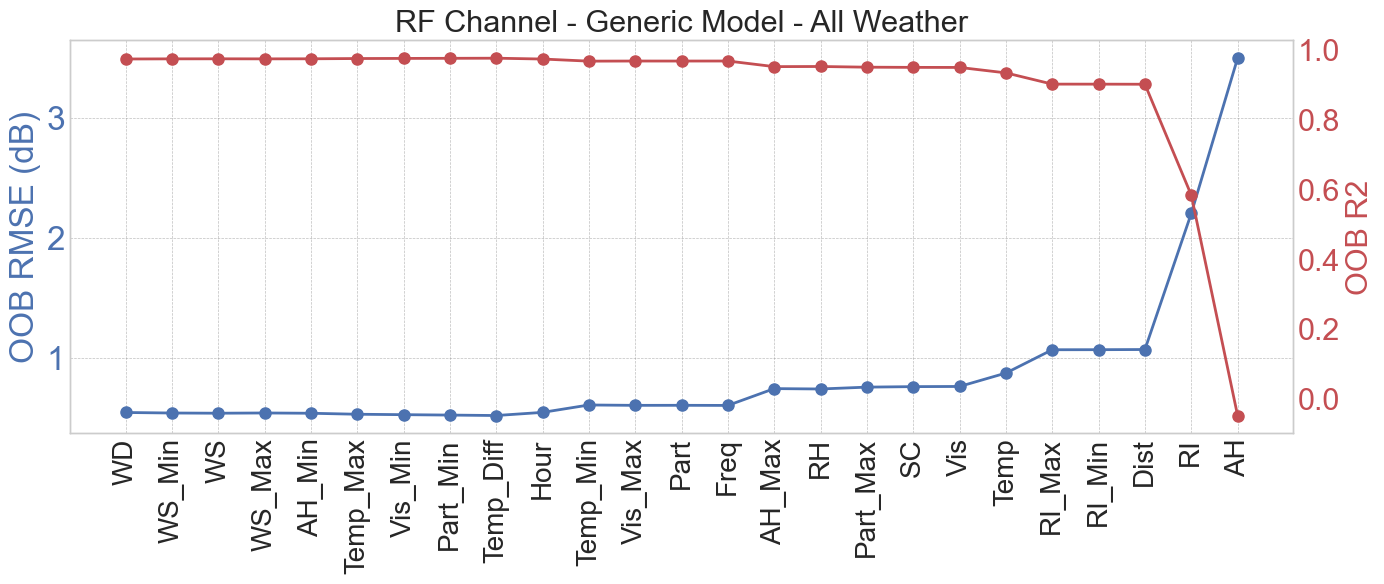

In [40]:
plot_feature_rank(RF_Generic_results["important_features"], 
                                   RF_Generic_results["rmse_list"], 
                                   RF_Generic_results["r2_list"],
                                   file_prefix="RF_Generic")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


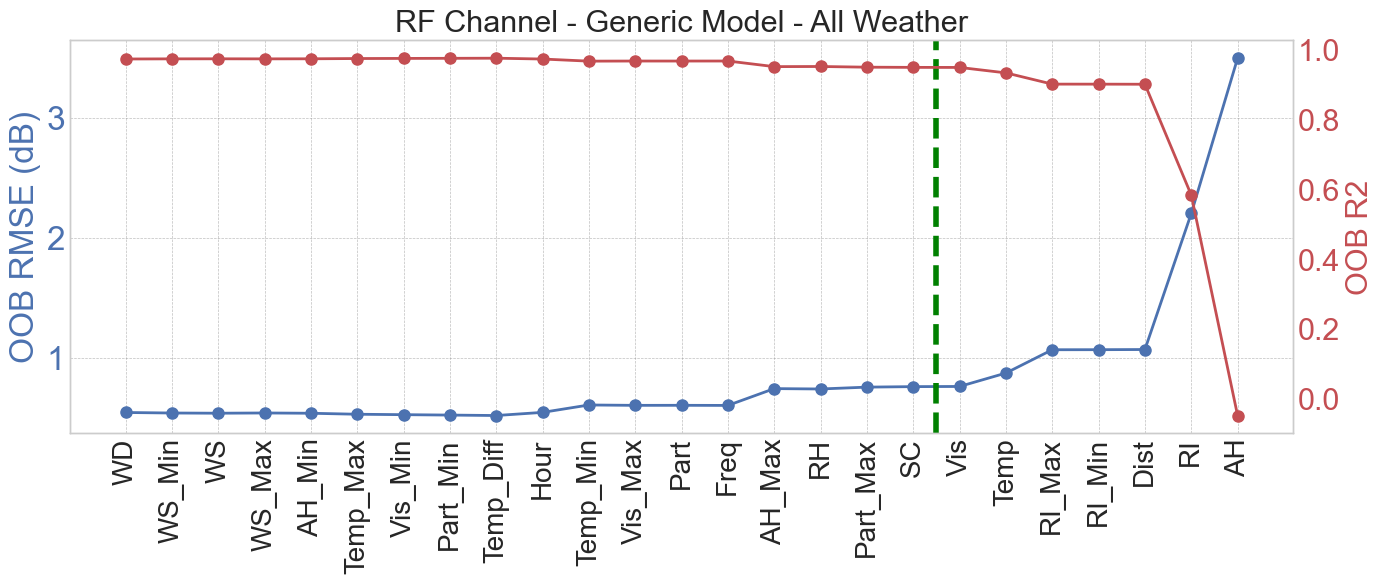

In [41]:
plot_green_line(RF_Generic_results["important_features"], 
                RF_Generic_results["rmse_list"], 
                RF_Generic_results["r2_list"],
                file_prefix="RF_Generic",
                point="SC")

In [42]:
save_important_features(RF_Generic_results["important_features"], 
                        point="SC", 
                        file_prefix="RF_Generic", 
                        output_dict=important_features)

Updated important features for RF - Generic: ['Vis', 'Temp', 'RI_Max', 'RI_Min', 'Dist', 'RI', 'AH']


**(4) Feature Selection for Specific Model on RF Attenuation**

In [43]:
RF_Specific0_results = feature_selection(X_data["X_Specific0"], y_data_RF["y_Specific0_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


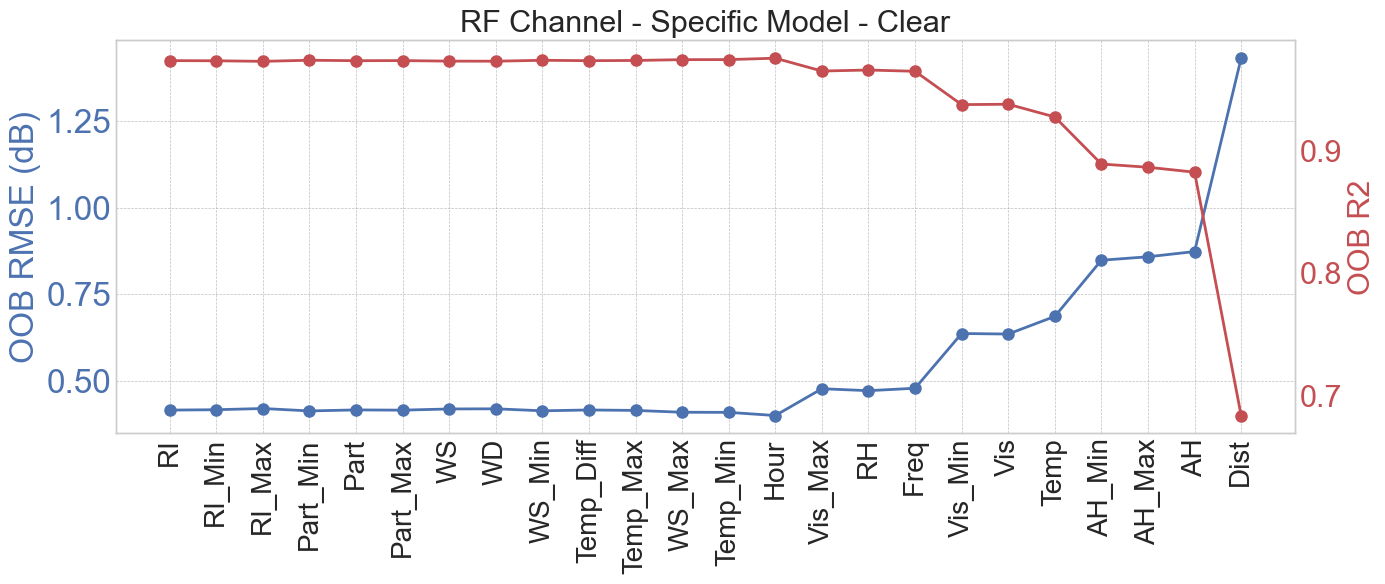

In [44]:
plot_feature_rank(RF_Specific0_results["important_features"], 
                  RF_Specific0_results["rmse_list"], 
                  RF_Specific0_results["r2_list"],
                  file_prefix="RF_Specific_0")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


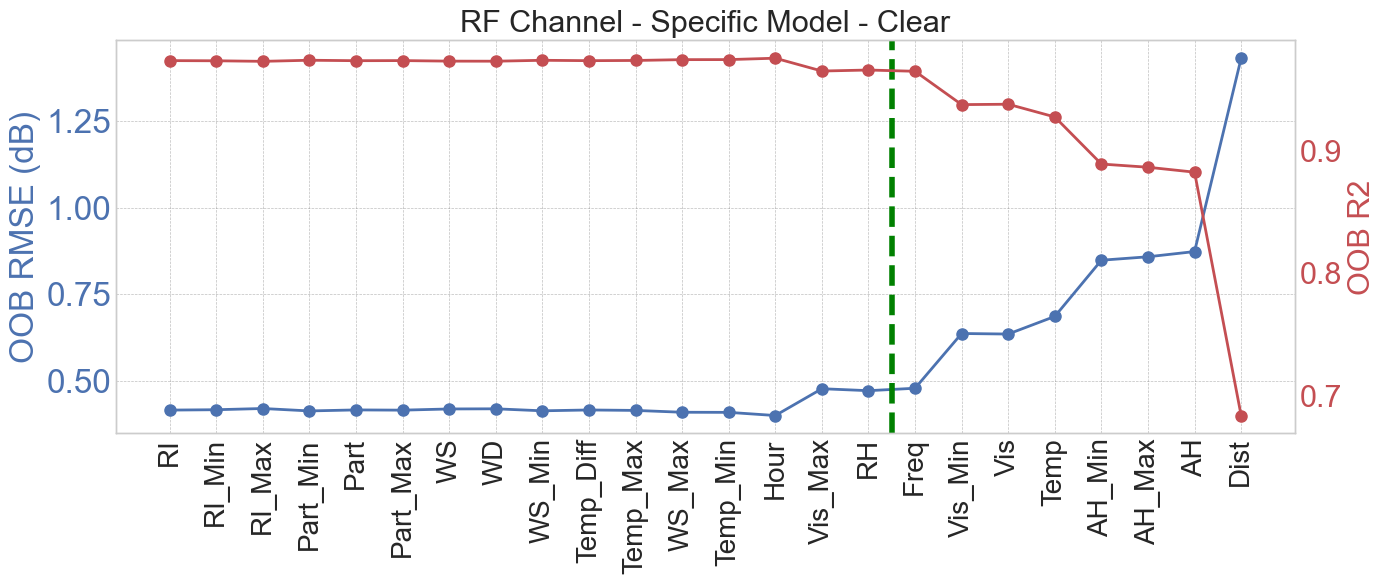

In [45]:
plot_green_line(RF_Specific0_results["important_features"], 
                RF_Specific0_results["rmse_list"], 
                RF_Specific0_results["r2_list"],
                file_prefix="RF_Specific_0",
                point="RH")

In [46]:
save_important_features(RF_Specific0_results["important_features"],
                        point="RH", 
                        file_prefix="RF_Specific0", 
                        output_dict=important_features)

Updated important features for RF - Specific0: ['Freq', 'Vis_Min', 'Vis', 'Temp', 'AH_Min', 'AH_Max', 'AH', 'Dist']


In [47]:
RF_Specific3_results = feature_selection(X_data["X_Specific3"], y_data_RF["y_Specific3_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


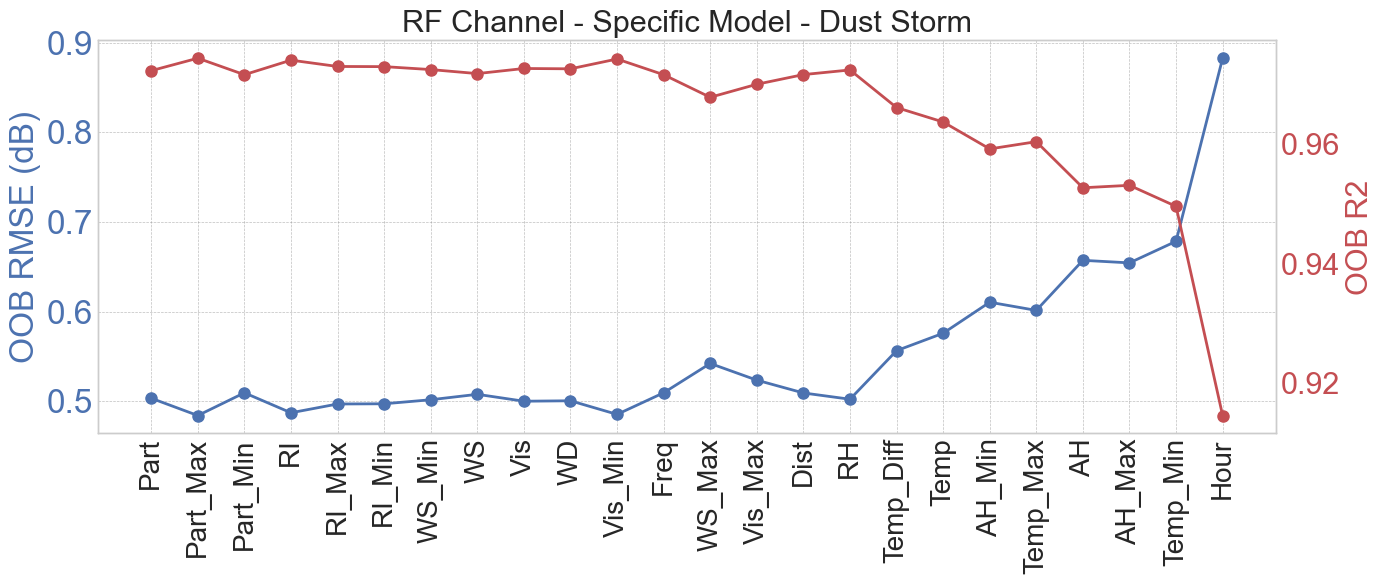

In [48]:
plot_feature_rank(RF_Specific3_results["important_features"], 
                  RF_Specific3_results["rmse_list"], 
                  RF_Specific3_results["r2_list"],
                  file_prefix="RF_Specific_3")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


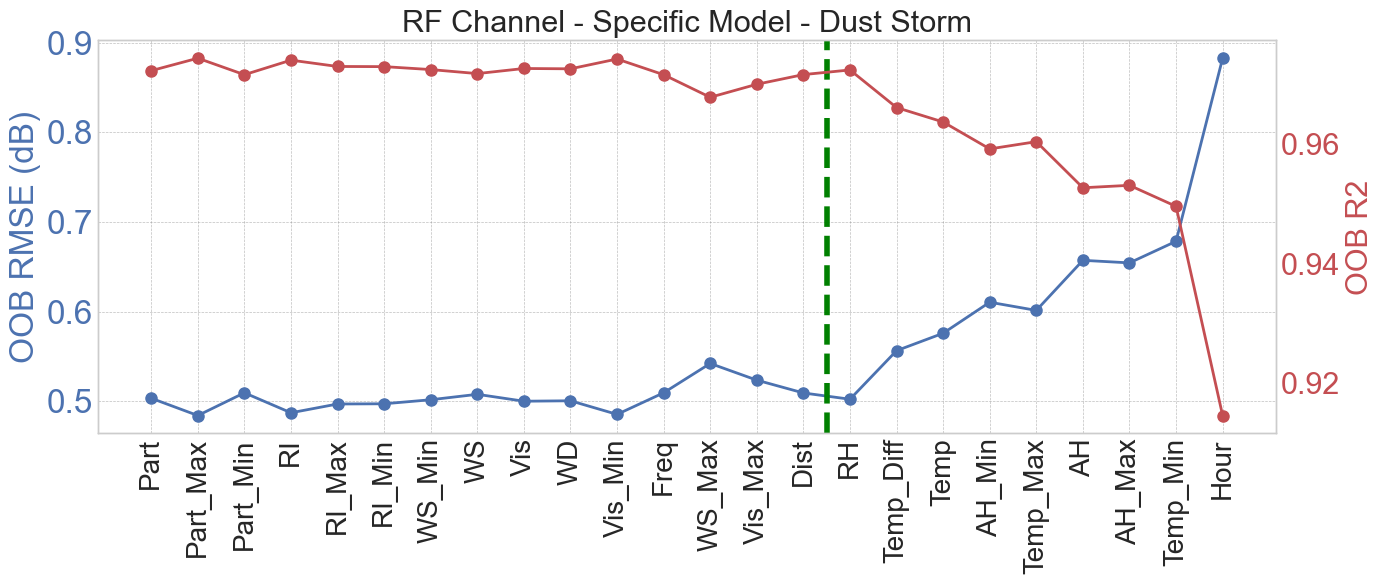

In [49]:
plot_green_line(RF_Specific3_results["important_features"], 
                RF_Specific3_results["rmse_list"], 
                RF_Specific3_results["r2_list"],
                file_prefix="RF_Specific_3",
                point="Dist")

In [50]:
save_important_features(RF_Specific3_results["important_features"],
                        point="Dist", 
                        file_prefix="RF_Specific3", 
                        output_dict=important_features)

Updated important features for RF - Specific3: ['RH', 'Temp_Diff', 'Temp', 'AH_Min', 'Temp_Max', 'AH', 'AH_Max', 'Temp_Min', 'Hour']


In [51]:
RF_Specific4_results = feature_selection(X_data["X_Specific4"], y_data_RF["y_Specific4_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


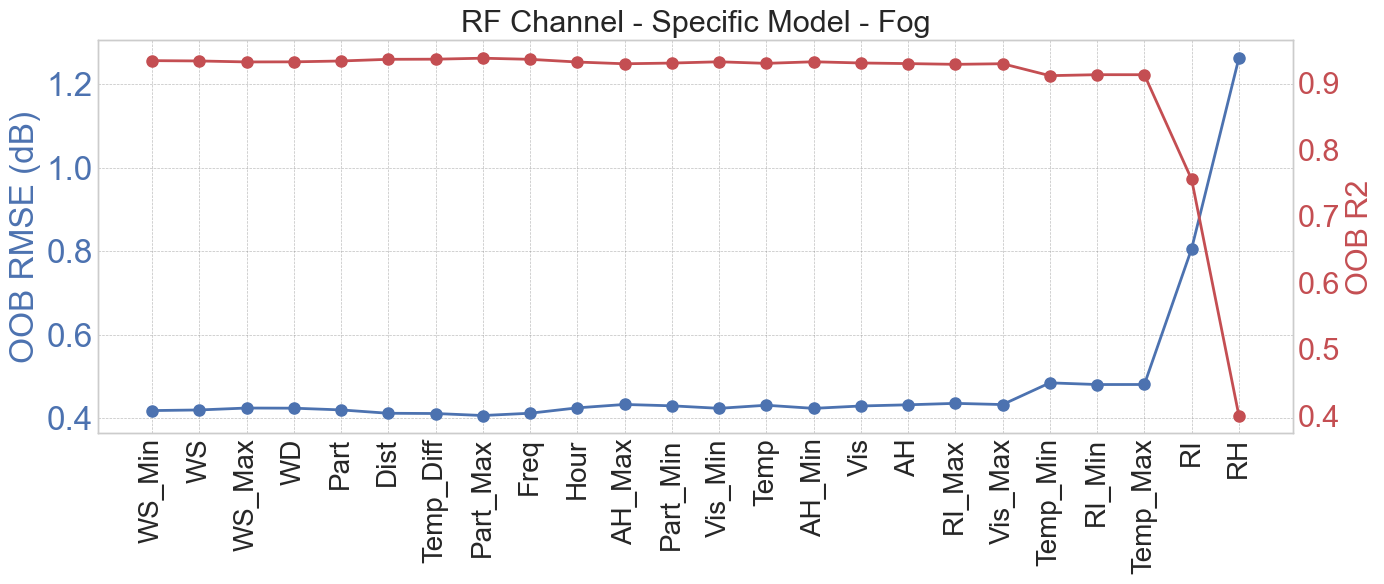

In [52]:
plot_feature_rank(RF_Specific4_results["important_features"], 
                  RF_Specific4_results["rmse_list"], 
                  RF_Specific4_results["r2_list"],
                  file_prefix="RF_Specific_4")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


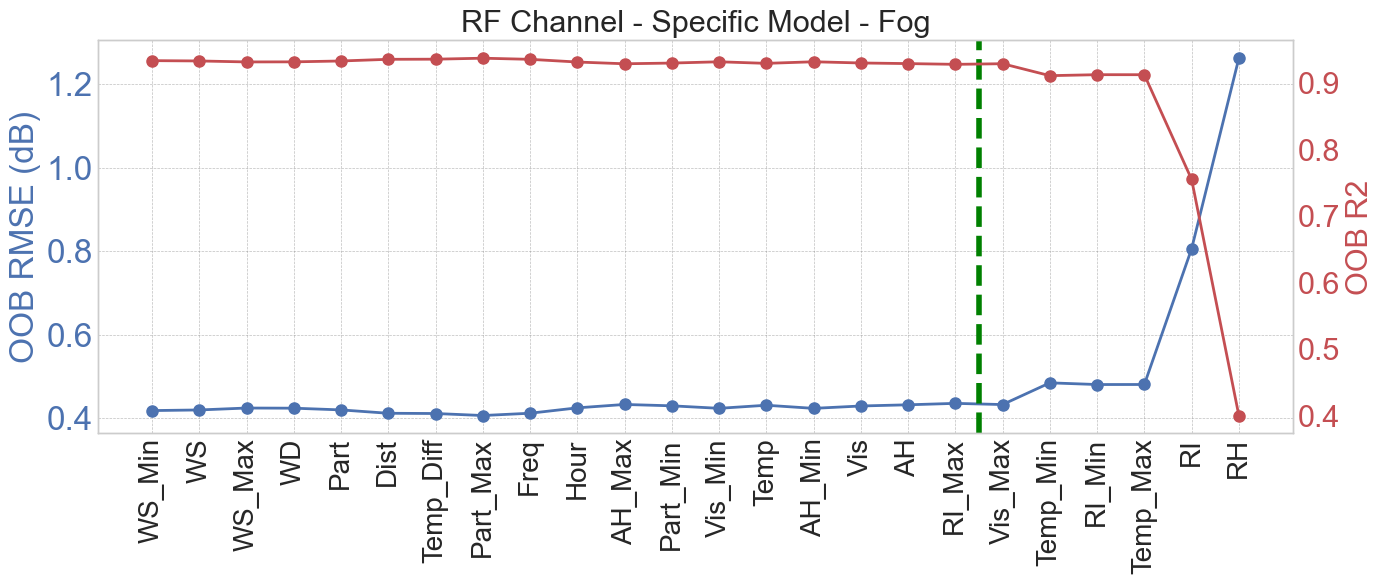

In [53]:
plot_green_line(RF_Specific4_results["important_features"], 
                RF_Specific4_results["rmse_list"], 
                RF_Specific4_results["r2_list"],
                file_prefix="RF_Specific_4",
                point="RI_Max")

In [54]:
save_important_features(RF_Specific4_results["important_features"],
                        point="RI_Max", 
                        file_prefix="RF_Specific4", 
                        output_dict=important_features)

Updated important features for RF - Specific4: ['Vis_Max', 'Temp_Min', 'RI_Min', 'Temp_Max', 'RI', 'RH']


In [55]:
RF_Specific5_results = feature_selection(X_data["X_Specific5"], y_data_RF["y_Specific5_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


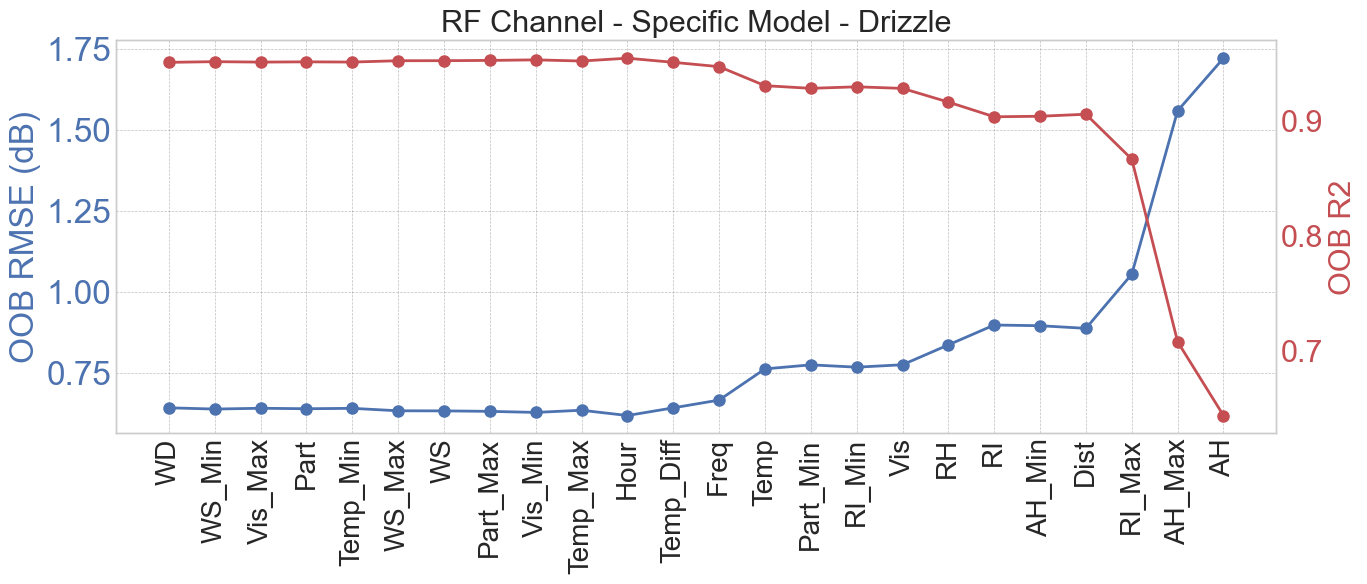

In [56]:
plot_feature_rank(RF_Specific5_results["important_features"], 
                  RF_Specific5_results["rmse_list"], 
                  RF_Specific5_results["r2_list"],
                  file_prefix="RF_Specific_5")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


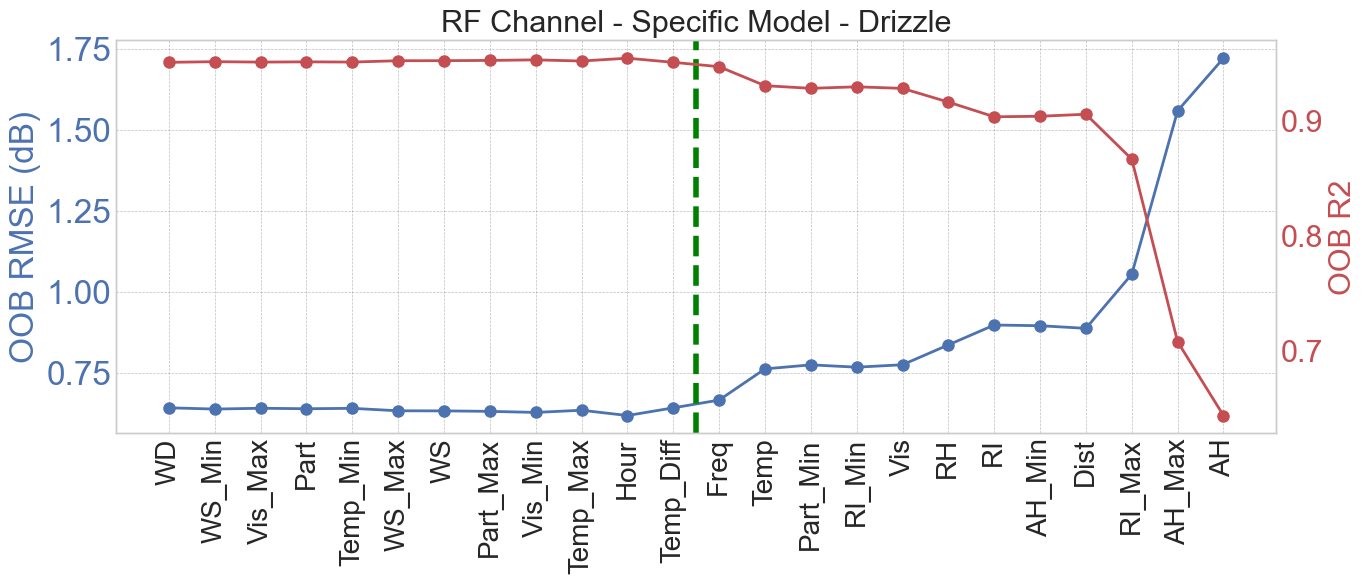

In [57]:
plot_green_line(RF_Specific5_results["important_features"], 
                RF_Specific5_results["rmse_list"], 
                RF_Specific5_results["r2_list"],
                file_prefix="RF_Specific_5",
                point="Temp_Diff")

In [58]:
save_important_features(RF_Specific5_results["important_features"],
                        point="Temp_Diff", 
                        file_prefix="RF_Specific5", 
                        output_dict=important_features)

Updated important features for RF - Specific5: ['Freq', 'Temp', 'Part_Min', 'RI_Min', 'Vis', 'RH', 'RI', 'AH_Min', 'Dist', 'RI_Max', 'AH_Max', 'AH']


In [59]:
RF_Specific6_results = feature_selection(X_data["X_Specific6"], y_data_RF["y_Specific6_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


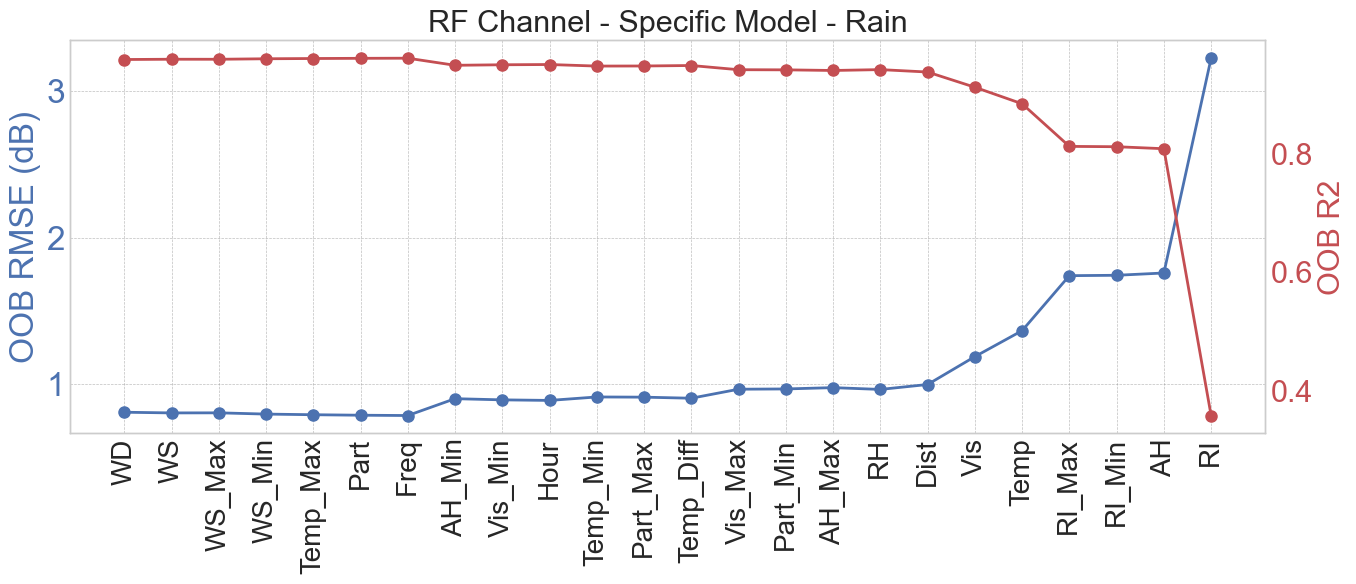

In [60]:
plot_feature_rank(RF_Specific6_results["important_features"], 
                  RF_Specific6_results["rmse_list"], 
                  RF_Specific6_results["r2_list"],
                  file_prefix="RF_Specific_6")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


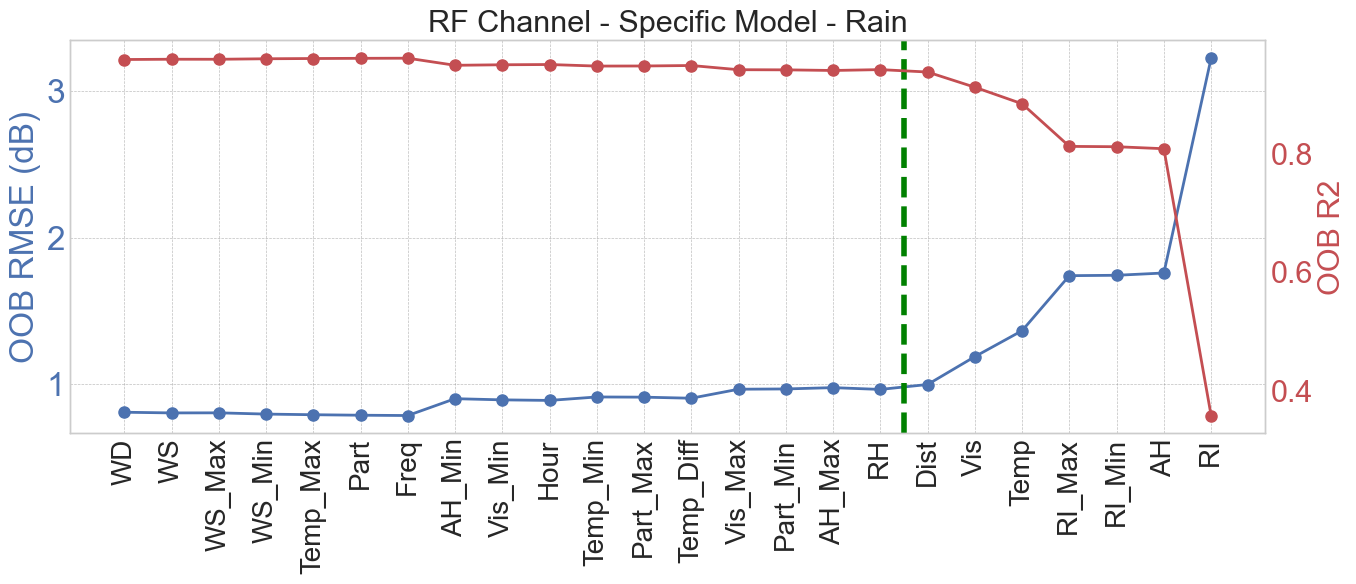

In [61]:
plot_green_line(RF_Specific6_results["important_features"], 
                RF_Specific6_results["rmse_list"], 
                RF_Specific6_results["r2_list"],
                file_prefix="RF_Specific_6",
                point="RH")

In [62]:
save_important_features(RF_Specific6_results["important_features"],
                        point="RH", 
                        file_prefix="RF_Specific6", 
                        output_dict=important_features)

Updated important features for RF - Specific6: ['Dist', 'Vis', 'Temp', 'RI_Max', 'RI_Min', 'AH', 'RI']


In [63]:
RF_Specific7_results = feature_selection(X_data["X_Specific7"], y_data_RF["y_Specific7_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


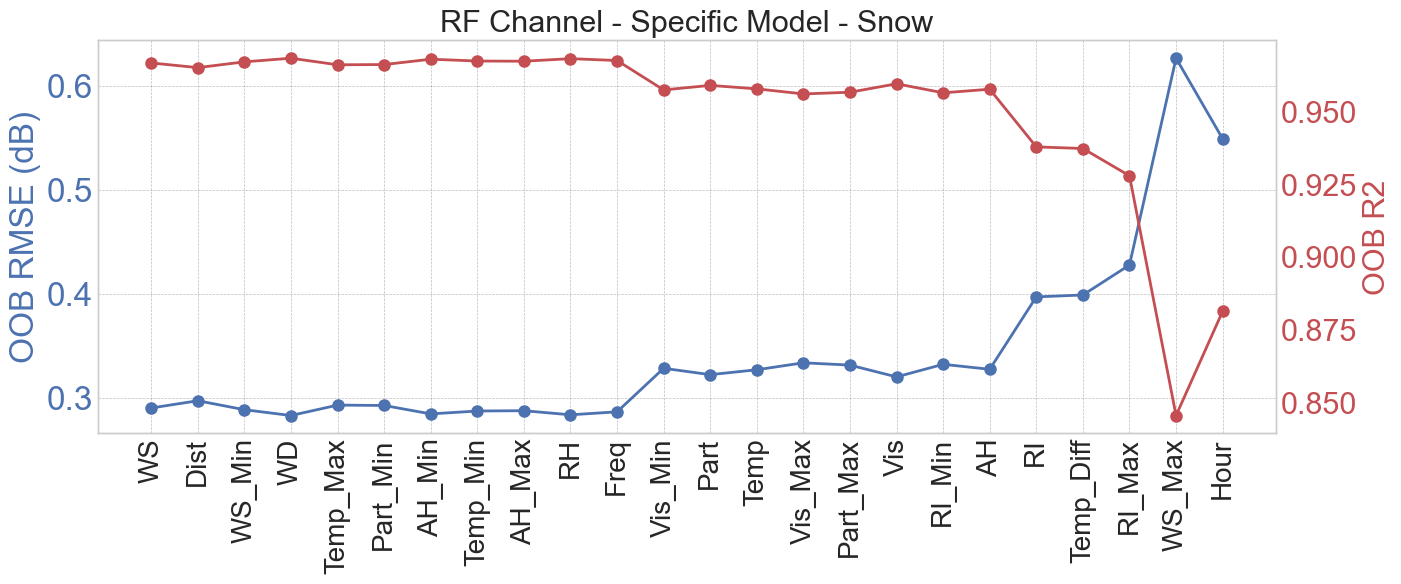

In [64]:
plot_feature_rank(RF_Specific7_results["important_features"], 
                  RF_Specific7_results["rmse_list"], 
                  RF_Specific7_results["r2_list"],
                  file_prefix="RF_Specific_7")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


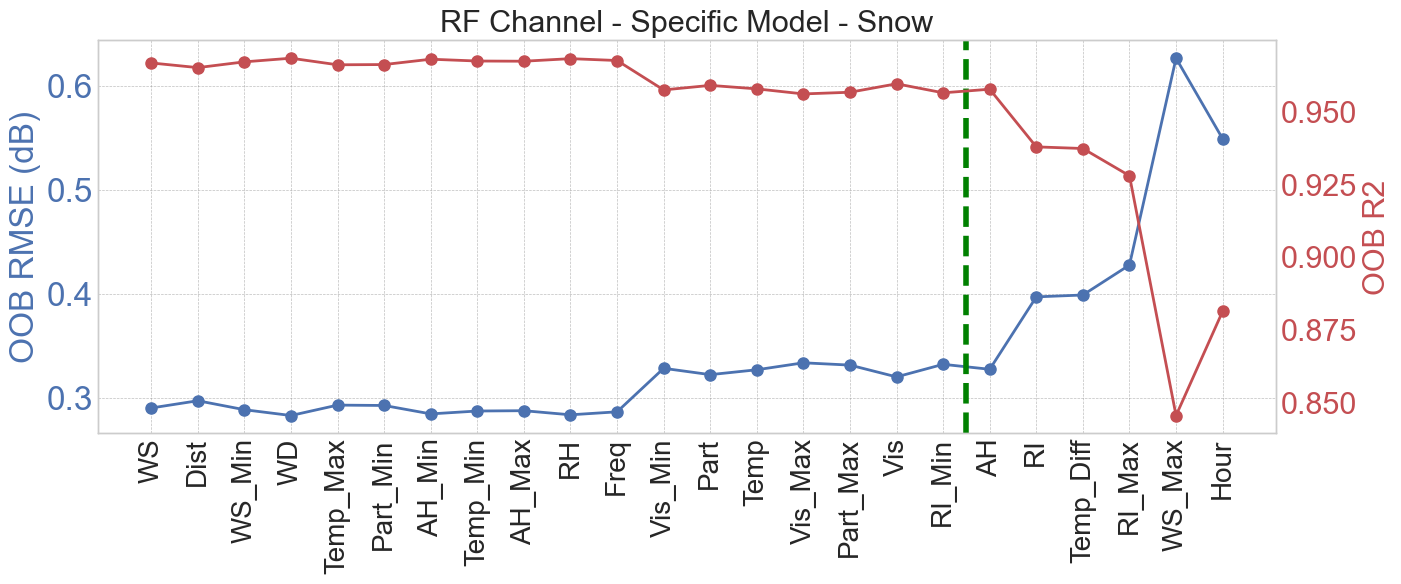

In [65]:
plot_green_line(RF_Specific7_results["important_features"], 
                RF_Specific7_results["rmse_list"], 
                RF_Specific7_results["r2_list"],
                file_prefix="RF_Specific_7",
                point="RI_Min")

In [66]:
save_important_features(RF_Specific7_results["important_features"],
                        point="RI_Min", 
                        file_prefix="RF_Specific7", 
                        output_dict=important_features)

Updated important features for RF - Specific7: ['AH', 'RI', 'Temp_Diff', 'RI_Max', 'WS_Max', 'Hour']


In [67]:
RF_Specific8_results = feature_selection(X_data["X_Specific8"], y_data_RF["y_Specific8_RF"])

Feature Selection Complete


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


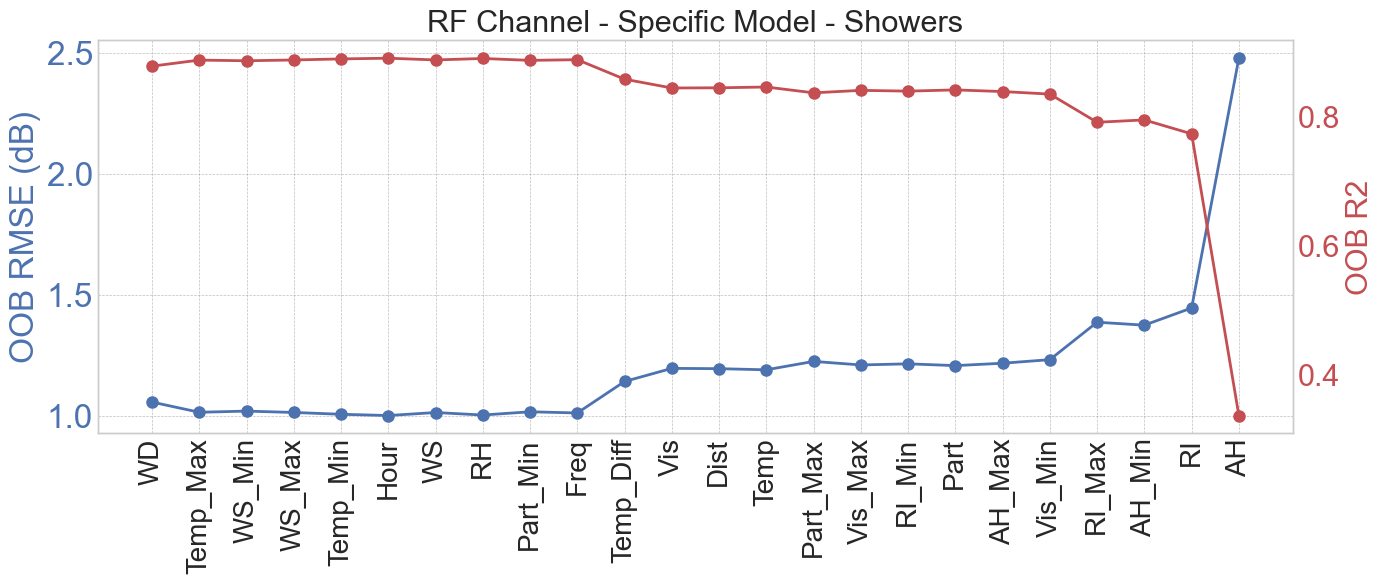

In [68]:
plot_feature_rank(RF_Specific8_results["important_features"], 
                                   RF_Specific8_results["rmse_list"], 
                                   RF_Specific8_results["r2_list"],
                                   file_prefix="RF_Specific_8")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


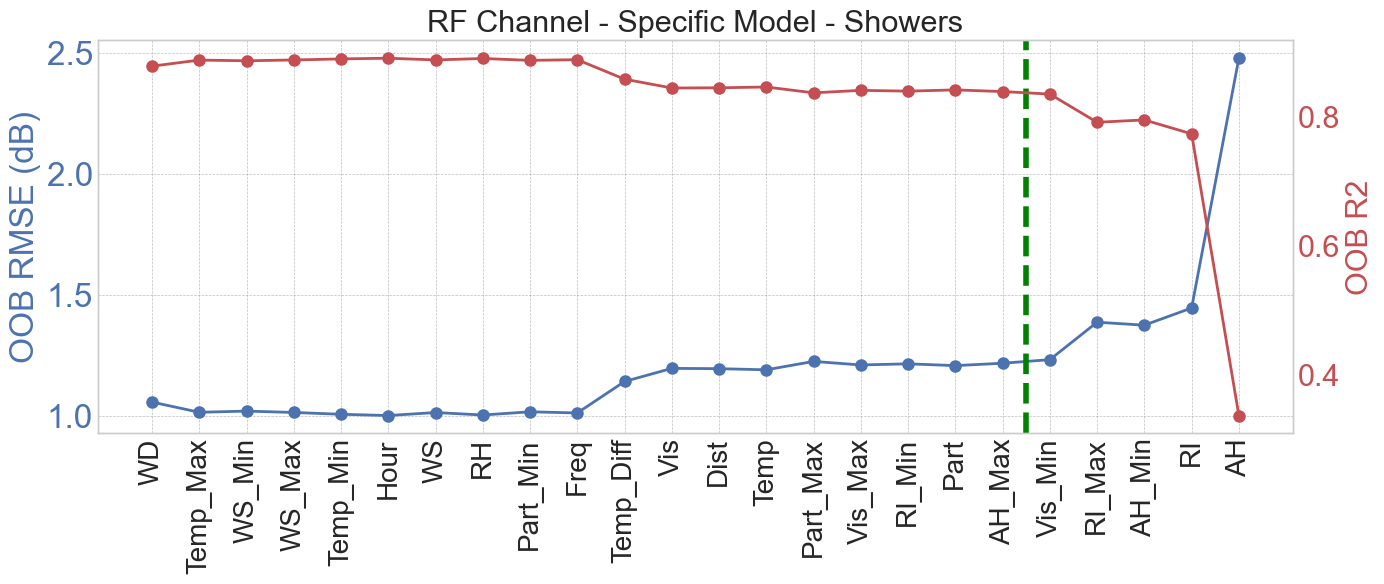

In [69]:
plot_green_line(RF_Specific8_results["important_features"], 
                RF_Specific8_results["rmse_list"], 
                RF_Specific8_results["r2_list"],
                file_prefix="RF_Specific_8",
                point="AH_Max")

In [70]:
save_important_features(RF_Specific8_results["important_features"],
                        point="AH_Max", 
                        file_prefix="RF_Specific8", 
                        output_dict=important_features)

Updated important features for RF - Specific8: ['Vis_Min', 'RI_Max', 'AH_Min', 'RI', 'AH']


**(5) Training Sets After Feature Selection**

In [78]:
# Function to load, filter, and save datasets based on important features
def process_and_save_datasets(X_data, important_features, channel, dataset_type):
    """
    Process and save datasets for each model based on the important features.

    Parameters:
    - X_data (dict): Dictionary containing datasets for each model.
    - important_features (dict): Dictionary of important features for each model.
    - channel (str): The channel type ("FSO" or "RF").
    - dataset_type (str): Type of dataset ("Train", "Validation", "Test").
    """
    base_dir = f"Data/Splitting/{dataset_type}"
    
    for model_name, features in important_features[channel].items():
        if model_name in X_data:
            # Load dataset
            X = X_data[model_name]

            # Select only important features
            X_filtered = X[features]

            # Determine the output directory based on model type
            if model_name == "Generic":
                output_dir = f"{base_dir}/Generic/X"
            else:
                output_dir = f"{base_dir}/Specific/X"

            # Create the directory if it doesn't exist
            os.makedirs(output_dir, exist_ok=True)

            # Save the filtered dataset with the prefix "updated_"
            output_file = os.path.join(output_dir, f"updated_{model_name}_{channel}.csv")
            X_filtered.to_csv(output_file, index=False)
            print(f"Saved filtered dataset for {channel} - {model_name} to {output_file}")
        else:
            print(f"Warning: Dataset for {model_name} not found in X_data.")

In [79]:
# Load datasets
X_train_data = {
    'Generic': pd.read_csv("Data/Splitting/Train/Generic/X/X_train.csv"),
    'Specific0': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_0.csv"),
    'Specific3': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_3.csv"),
    'Specific4': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_4.csv"),
    'Specific5': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_5.csv"),
    'Specific6': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_6.csv"),
    'Specific7': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_7.csv"),
    'Specific8': pd.read_csv("Data/Splitting/Train/Specific/X/train_X_SC_8.csv")
}

In [80]:
# Process and save datasets
process_and_save_datasets(X_train_data, important_features, "FSO", "Train")
process_and_save_datasets(X_train_data, important_features, "RF", "Train")

print("New training datasets with important features for FSO and RF created successfully.")

Saved filtered dataset for FSO - Generic to Data/Splitting/Train/Generic/X/updated_Generic_FSO.csv
Saved filtered dataset for FSO - Specific0 to Data/Splitting/Train/Specific/X/updated_Specific0_FSO.csv
Saved filtered dataset for FSO - Specific3 to Data/Splitting/Train/Specific/X/updated_Specific3_FSO.csv
Saved filtered dataset for FSO - Specific4 to Data/Splitting/Train/Specific/X/updated_Specific4_FSO.csv
Saved filtered dataset for FSO - Specific5 to Data/Splitting/Train/Specific/X/updated_Specific5_FSO.csv
Saved filtered dataset for FSO - Specific6 to Data/Splitting/Train/Specific/X/updated_Specific6_FSO.csv
Saved filtered dataset for FSO - Specific7 to Data/Splitting/Train/Specific/X/updated_Specific7_FSO.csv
Saved filtered dataset for FSO - Specific8 to Data/Splitting/Train/Specific/X/updated_Specific8_FSO.csv
Saved filtered dataset for RF - Generic to Data/Splitting/Train/Generic/X/updated_Generic_RF.csv
Saved filtered dataset for RF - Specific0 to Data/Splitting/Train/Specific/X

**(6) Validation Sets After Feature Selection**

In [81]:
# Create directories to save the files if they don't already exist
os.makedirs("Data/Splitting/Validation/Generic/X", exist_ok=True)
os.makedirs("Data/Splitting/Validation/Generic/Y", exist_ok=True)

# Define important features for FSO and RF (Generic only)
generic_features_FSO = important_features['FSO']['Generic']
generic_features_RF = important_features['RF']['Generic']

# Define paths for the validation datasets
X_val_paths = {
    'Generic': "Data/Splitting/Validation/Generic/X/X_val.csv",
    'Specific0': "Data/Splitting/Validation/Specific/X/val_X_SC_0.csv",
    'Specific3': "Data/Splitting/Validation/Specific/X/val_X_SC_3.csv",
    'Specific4': "Data/Splitting/Validation/Specific/X/val_X_SC_4.csv",
    'Specific5': "Data/Splitting/Validation/Specific/X/val_X_SC_5.csv",
    'Specific6': "Data/Splitting/Validation/Specific/X/val_X_SC_6.csv",
    'Specific7': "Data/Splitting/Validation/Specific/X/val_X_SC_7.csv",
    'Specific8': "Data/Splitting/Validation/Specific/X/val_X_SC_8.csv",
}

# Loop over each dataset and create a new one with only Generic features
for name, path in X_val_paths.items():
    # Load the dataset
    X_val = pd.read_csv(path)
    
    # Select only the Generic important features for FSO and RF
    X_fso_generic = X_val[generic_features_FSO]
    X_rf_generic = X_val[generic_features_RF]
    
    # Save the new datasets
    X_fso_generic.to_csv(f"Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_{name}.csv", index=False)
    X_rf_generic.to_csv(f"Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_{name}.csv", index=False)

print("New validation datasets with Generic important features for FSO and RF created successfully.")

New validation datasets with Generic important features for FSO and RF created successfully.


In [82]:
# Load datasets
X_val_data = {
    'Generic': pd.read_csv("Data/Splitting/Validation/Generic/X/X_val.csv"),
    'Specific0': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_0.csv"),
    'Specific3': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_3.csv"),
    'Specific4': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_4.csv"),
    'Specific5': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_5.csv"),
    'Specific6': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_6.csv"),
    'Specific7': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_7.csv"),
    'Specific8': pd.read_csv("Data/Splitting/Validation/Specific/X/val_X_SC_8.csv")
}

# Process and save datasets
process_and_save_datasets(X_val_data, important_features, "FSO", "Validation")
process_and_save_datasets(X_val_data, important_features, "RF", "Validation")

print("New validation datasets with Specific important features for FSO and RF created successfully.")

Saved filtered dataset for FSO - Generic to Data/Splitting/Validation/Generic/X/updated_Generic_FSO.csv
Saved filtered dataset for FSO - Specific0 to Data/Splitting/Validation/Specific/X/updated_Specific0_FSO.csv
Saved filtered dataset for FSO - Specific3 to Data/Splitting/Validation/Specific/X/updated_Specific3_FSO.csv
Saved filtered dataset for FSO - Specific4 to Data/Splitting/Validation/Specific/X/updated_Specific4_FSO.csv
Saved filtered dataset for FSO - Specific5 to Data/Splitting/Validation/Specific/X/updated_Specific5_FSO.csv
Saved filtered dataset for FSO - Specific6 to Data/Splitting/Validation/Specific/X/updated_Specific6_FSO.csv
Saved filtered dataset for FSO - Specific7 to Data/Splitting/Validation/Specific/X/updated_Specific7_FSO.csv
Saved filtered dataset for FSO - Specific8 to Data/Splitting/Validation/Specific/X/updated_Specific8_FSO.csv
Saved filtered dataset for RF - Generic to Data/Splitting/Validation/Generic/X/updated_Generic_RF.csv
Saved filtered dataset for RF -